In [1]:
# подключение библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

In [2]:
#загрузка данных
df = pd.read_csv('dataset_segment_bank.csv')

In [3]:
#просмотр датафрейма
df.head(2)

,Идентификатор,Дата рождения,Дисциплина клиентов без просрочки по кредиту,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,Максимальная сумма перевода,Средняя сумма перевода,Полная сумма перевода,"Канал, через который пришел клиент",Оператор связи,Пол
0,1493553,1981-05-08,BAD,17.0,2.0,77.0,77.0,371600.0,265000.0,21858.8235,371600.0,Стойка,NaN,Ж
1,8130758,1979-03-06,BAD,4.0,2.0,77.0,77.0,137574.0,135000.0,34393.5000,137574.0,Стойка,NaN,М


In [4]:
# просмотр сводной информации датафрейма
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50224 entries, 0 to 50223
Data columns (total 14 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Идентификатор                                 50224 non-null  int64  
 1   Дата рождения                                 50224 non-null  str    
 2   Дисциплина клиентов без просрочки по кредиту  50223 non-null  str    
 3   Количество переводов                          50158 non-null  float64
 4   Тип переводов                                 50191 non-null  float64
 5   География переводов                           50191 non-null  float64
 6   География телефона                            48324 non-null  float64
 7   Сумма перевода                                50158 non-null  float64
 8   Максимальная сумма перевода                   50158 non-null  float64
 9   Средняя сумма перевода                        50158 non-null  float64
 1

- заменить типы данных
- заголовки корректировать не нужно
- есть пропуски




In [5]:
#корректировка типа данных 
df = df.astype({'Дата рождения': 'datetime64[ms]'})

In [6]:
#проверка дублирующихся записей 
# поиск и обработка дублирующихся записей;
df.duplicated().sum()

# просмотр дублирующихся записей
flt = df.duplicated()
df.loc[flt]

,Идентификатор,Дата рождения,Дисциплина клиентов без просрочки по кредиту,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,Максимальная сумма перевода,Средняя сумма перевода,Полная сумма перевода,"Канал, через который пришел клиент",Оператор связи,Пол
285,13429088,1984-09-12,MIDDLE,89.0,2.0,77.0,33.0,573174.03,25950.0,6440.1576,573174.03,Партнер,Вотек Мобайл,М
334,13429088,1984-09-12,MIDDLE,89.0,2.0,77.0,33.0,573174.03,25950.0,6440.1576,573174.03,Партнер,Вотек Мобайл,М
459,17591794,1974-09-28,MIDDLE,22.0,5.0,77.0,NaN,78746.00,10200.0,3579.3636,78746.00,Партнер,Мобильные ТелеСистемы,М
466,17591794,1974-09-28,MIDDLE,22.0,5.0,77.0,NaN,78746.00,10200.0,3579.3636,78746.00,Партнер,Мобильные ТелеСистемы,М
528,4872767,1968-02-18,BAD,13.0,2.0,77.0,77.0,316064.16,150000.0,24312.6276,316064.16,Стойка,NaN,М
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50149,8551974,1979-12-02,GOOD,471.0,16.0,77.0,23.0,2029892.53,30000.0,4309.7505,2029892.53,Партнер,Вымпел-Коммуникации,М
50150,8551974,1979-12-02,GOOD,471.0,16.0,77.0,23.0,2029892.53,30000.0,4309.7505,2029892.53,Партнер,Вымпел-Коммуникации,М
50151,8551974,1979-12-02,GOOD,471.0,16.0,77.0,23.0,2029892.53,30000.0,4309.7505,2029892.53,Партнер,Вымпел-Коммуникации,М
50152,8551974,1979-12-02,GOOD,471.0,16.0,77.0,23.0,2029892.53,30000.0,4309.7505,2029892.53,Партнер,Вымпел-Коммуникации,М


In [7]:
# удалить дубли
df = df.drop_duplicates()

In [8]:
# посмотрим на статистические показатели, для числовых столбцов
df.describe()

,Идентификатор,Дата рождения,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,Максимальная сумма перевода,Средняя сумма перевода,Полная сумма перевода
count,4.964900e+04,49649,49583.000000,49616.000000,49616.000000,47781.000000,4.958300e+04,4.958300e+04,49583.000000,4.958300e+04
mean,1.097182e+07,1970-08-30 08:16:53.385000,15.886130,13.224484,110.669744,58.206735,2.943397e+05,1.680532e+05,34735.108103,2.943397e+05
min,1.400402e+06,1940-01-20 00:00:00,1.000000,-1.000000,0.000000,0.000000,3.000000e+01,3.000000e+01,30.000000,3.000000e+01
25%,6.377852e+06,1962-04-28 00:00:00,4.000000,2.000000,48.000000,42.000000,9.137250e+04,5.500000e+04,10254.507200,9.137250e+04
50%,1.134104e+07,1971-04-29 00:00:00,9.000000,5.000000,73.000000,66.000000,1.857500e+05,1.200000e+05,20049.153800,1.857500e+05
75%,1.444320e+07,1979-06-28 00:00:00,17.000000,6.000000,77.000000,77.000000,3.759768e+05,2.350000e+05,41927.295450,3.759768e+05
max,3.006527e+07,1991-09-20 00:00:00,2220.000000,69.000000,498002.000000,78.000000,1.953691e+07,2.150000e+06,644225.000000,1.953691e+07
std,5.763481e+06,NaN,29.672765,22.350063,4998.489682,22.707858,4.486187e+05,1.408856e+05,43694.270643,4.486187e+05


столбцы "Сумма перевода" и "Полная сумма перевода" совпадают, удалим столбец "Полная сумма перевода"

столбцы "Максимальная сумма перевода" и "Средняя сумма перевода" можно расчитать, удаляем

аномалии:

- в столбце "Количество переводов" мах значение перевода
- в столбце "Тип переводов" мин значение перевода
- в столбце "География переводов" мин и мах значения
- в столбце "География телефона" мин значение




In [9]:
#удалить столбцы "Полная сумма перевода", "Максимальная сумма перевода" и "Средняя сумма перевода"
df = df.drop(columns=['Полная сумма перевода', 'Максимальная сумма перевода', 'Средняя сумма перевода'])

In [10]:
# добавить колонку с возрастом клиенов
today = pd.Timestamp.today()
df['Возраст'] = (today - df['Дата рождения']).dt.days // 365

In [11]:
df.head()

,Идентификатор,Дата рождения,Дисциплина клиентов без просрочки по кредиту,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,"Канал, через который пришел клиент",Оператор связи,Пол,Возраст
0,1493553,1981-05-08,BAD,17.0,2.0,77.0,77.0,371600.00,Стойка,NaN,Ж,45
1,8130758,1979-03-06,BAD,4.0,2.0,77.0,77.0,137574.00,Стойка,NaN,М,47
2,1782539,1957-04-29,BAD,3.0,2.0,77.0,77.0,175150.00,Стойка,МегаФон,М,69
3,12410720,1977-08-05,BAD,3.0,2.0,77.0,77.0,50250.00,Стойка,NaN,М,49
4,21309736,1978-08-15,GOOD,5.0,69.0,77.0,77.0,215920.14,Стойка,NaN,М,48


In [12]:
#посмотрим на кол-во пропусков 
# Видим, что по некоторым столбцам кол-во пропусков совпадает, проанализируем
df.isnull().sum()

Идентификатор                                      0
Дата рождения                                      0
Дисциплина клиентов без просрочки по кредиту       1
Количество переводов                              66
Тип переводов                                     33
География переводов                               33
География телефона                              1868
Сумма перевода                                    66
Канал, через который пришел клиент                31
Оператор связи                                   644
Пол                                                9
Возраст                                            0
dtype: int64

In [13]:
# разделение на категориальные и количественные признаки
# поправим уникальные значения в столбце "Оператор связи"
lst_categpry = (['Дисциплина клиентов без просрочки по кредиту', 'Тип переводов', 'География переводов', 
                 'География телефона', 'Канал, через который пришел клиент', 'Пол', 'Оператор связи'])
lst_col = (['Количество переводов', 'Сумма перевода', 'Возраст'])

for var in lst_categpry:
    print(f'Уникальные значения признака - {var}')
    print(df[var].unique())
    print(f'----------')
    

Уникальные значения признака - Дисциплина клиентов без просрочки по кредиту
<StringArray>
['BAD', 'GOOD', 'MIDDLE', nan]
Length: 4, dtype: str
----------
Уникальные значения признака - Тип переводов
[ 2. 69.  1.  5.  8. 32.  0. 10. 26. 12.  6. 45. 11. 33. 16.  7. 37. 21.
 58. 19. 59. 44. 53. 28. 34.  3. 43. 29. 67. 17. 30. -1. 23. 55.  4. 61.
  9. 54. nan 49.]
----------
Уникальные значения признака - География переводов
[7.70000e+01 7.10000e+01 7.40000e+01 3.40000e+01 5.90000e+01 2.30000e+01
 4.20000e+01 3.90000e+01 6.30000e+01 1.60000e+01 3.60000e+01 6.10000e+01
 2.00000e+00 7.00000e+00 4.80000e+01 6.40000e+01 8.90000e+01 5.60000e+01
 6.20000e+01 6.60000e+01 7.30000e+01 4.30000e+01 3.30000e+01 0.00000e+00
 5.40000e+01 3.50000e+01 1.30000e+01 1.80000e+01 5.20000e+01 7.60000e+01
 5.50000e+01 6.90000e+01 7.80000e+01 2.60000e+01 3.00000e+01 6.80000e+01
 4.40000e+01 6.70000e+01 3.10000e+01 2.10000e+01 5.80000e+01 7.20000e+01
 4.70000e+01 5.30000e+01 4.00000e+01 4.98002e+05 1.00000e+01 5.1

In [14]:
# Заменяем ошибочные варианты на правильные
df['Оператор связи'] = df['Оператор связи'].replace({'МобильныеТелеСистемы': 'Мобильные ТелеСистемы',
                                                     'Ниж-ская сот.связь': 'Нижегородская сотовая связь',
                                                     'Сот.св.Башкортостана': 'Сотовая связь Башкортостана'})

In [15]:
percs = [0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
df.describe(percentiles=percs)

,Идентификатор,Дата рождения,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,Возраст
count,4.964900e+04,49649,49583.000000,49616.000000,49616.000000,47781.000000,4.958300e+04,49649.000000
mean,1.097182e+07,1970-08-30 08:16:53.385000,15.886130,13.224484,110.669744,58.206735,2.943397e+05,55.566316
min,1.400402e+06,1940-01-20 00:00:00,1.000000,-1.000000,0.000000,0.000000,3.000000e+01,34.000000
1%,1.552769e+06,1947-04-12 00:00:00,1.000000,0.000000,2.000000,2.000000,2.353525e+04,37.000000
5%,2.226812e+06,1952-02-01 19:12:00,2.000000,2.000000,13.000000,10.000000,3.993920e+04,39.000000
25%,6.377852e+06,1962-04-28 00:00:00,4.000000,2.000000,48.000000,42.000000,9.137250e+04,47.000000
50%,1.134104e+07,1971-04-29 00:00:00,9.000000,5.000000,73.000000,66.000000,1.857500e+05,55.000000
75%,1.444320e+07,1979-06-28 00:00:00,17.000000,6.000000,77.000000,77.000000,3.759768e+05,64.000000
90%,1.695423e+07,1984-12-29 00:00:00,35.000000,69.000000,77.000000,78.000000,6.076080e+05,71.000000
95%,2.210644e+07,1987-03-16 00:00:00,53.000000,69.000000,78.000000,78.000000,8.032824e+05,74.000000


In [16]:
# считаю, что в столбце "Количество переводов" указанное максимальное значение может быть таким:
# если данные собраны за месяц - это аномалия, требующая проверки (возможно, клиент — бизнес, или это ошибка в данных).
# если данные собраны за год - это активный пользователь (6 переводов в день).
# если данные собраны за 5 лет - это реалистичный показатель (1.2 перевода в день).
df.nlargest(10, 'Количество переводов')


,Идентификатор,Дата рождения,Дисциплина клиентов без просрочки по кредиту,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,"Канал, через который пришел клиент",Оператор связи,Пол,Возраст
49764,21366532,1964-06-06,MIDDLE,2220.0,37.0,34.0,34.0,8308411.72,Партнер,Вымпел-Коммуникации,Ж,62
50110,21411779,1973-04-15,MIDDLE,1571.0,16.0,64.0,64.0,549528.02,Офис,Вымпел-Коммуникации,Ж,53
50156,1602569,1961-05-27,MIDDLE,1094.0,16.0,77.0,77.0,1019370.70,Офис,МегаФон,Ж,65
15280,21011291,1983-08-01,GOOD,1043.0,16.0,63.0,63.0,450317.50,Офис,МегаФон,Ж,43
50123,3625399,1965-11-12,MIDDLE,954.0,2.0,77.0,77.0,1267971.32,Офис,Вымпел-Коммуникации,Ж,60
50028,3351510,1971-12-28,BAD,895.0,16.0,10.0,10.0,668060.69,Офис,Мобильные ТелеСистемы,Ж,54
50157,13095859,1959-04-28,GOOD,813.0,32.0,40.0,72.0,12870362.54,Партнер,Мобильные ТелеСистемы,Ж,67
50047,1444186,1987-06-14,BAD,781.0,2.0,48.0,23.0,6389174.67,Партнер,Вымпел-Коммуникации,Ж,39
19526,2236716,1972-09-09,GOOD,767.0,2.0,77.0,77.0,15004967.01,Офис,Вымпел-Коммуникации,М,54
50154,21585124,1970-06-30,GOOD,746.0,0.0,77.0,77.0,10036750.00,Офис,Вымпел-Коммуникации,М,56


In [17]:
# по данным мы видим, что 1,47% заполнено значение 0, можно рассмотреть вариант замены модой
df[df['Тип переводов'] == 0]

,Идентификатор,Дата рождения,Дисциплина клиентов без просрочки по кредиту,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,"Канал, через который пришел клиент",Оператор связи,Пол,Возраст
38,2736305,1983-04-25,BAD,3.0,0.0,77.0,77.0,275000.0,Офис,МегаФон,М,43
107,14857125,1968-02-17,BAD,13.0,0.0,2.0,2.0,101850.0,Партнер,МегаФон,М,58
116,2989108,1986-04-10,BAD,14.0,0.0,77.0,77.0,402150.0,Офис,NaN,Ж,40
205,2648219,1982-06-07,BAD,9.0,0.0,77.0,NaN,134000.0,Офис,МегаФон,Ж,44
210,15756532,1961-09-24,MIDDLE,49.0,0.0,77.0,77.0,620150.0,Офис,Вымпел-Коммуникации,Ж,64
...,...,...,...,...,...,...,...,...,...,...,...,...
49977,10362708,1987-06-18,MIDDLE,206.0,0.0,77.0,77.0,1941500.0,Офис,МегаФон,М,39
50004,7777404,1967-01-02,GOOD,213.0,0.0,77.0,77.0,2654256.0,Офис,МегаФон,М,59
50109,6961560,1980-12-01,MIDDLE,365.0,0.0,77.0,77.0,3821810.0,Офис,МегаФон,М,45
50154,21585124,1970-06-30,GOOD,746.0,0.0,77.0,77.0,10036750.0,Офис,Вымпел-Коммуникации,М,56


C:\Users\семейство Елисеевых\AppData\Local\Temp\ipykernel_1808\3556991087.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=geo.index.astype(str), y=geo.values, palette='viridis')


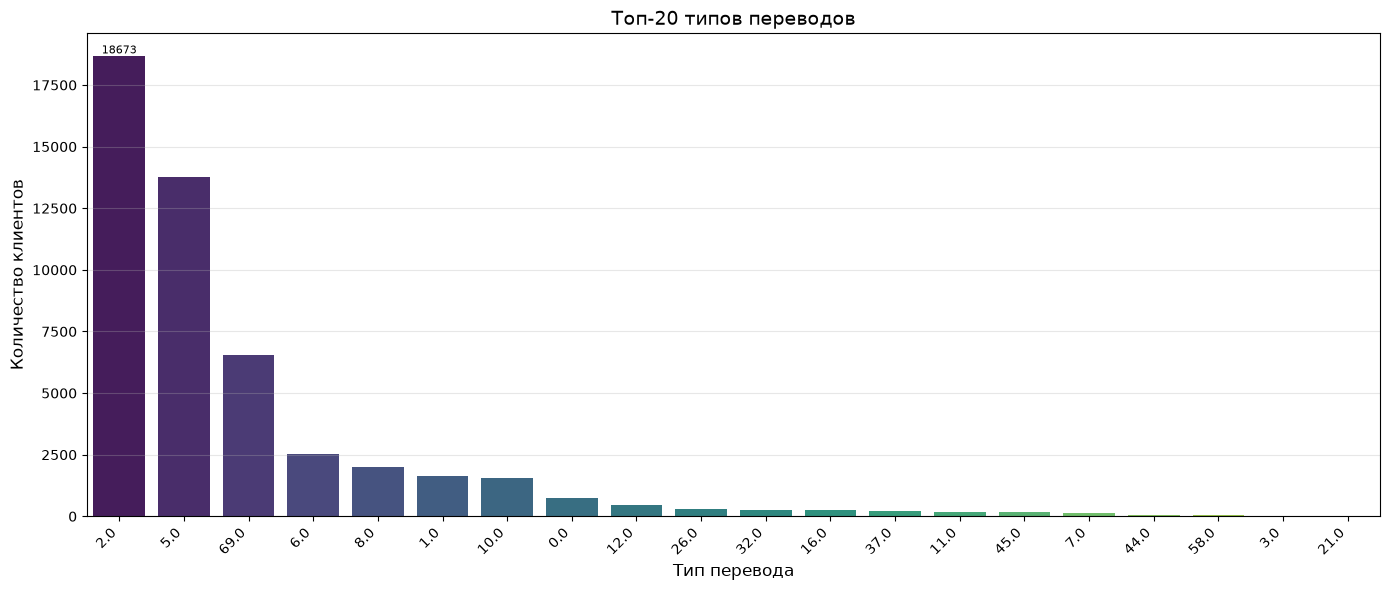

In [18]:
#посмотрим распределение по типу переводов, мы видим, что 2 код преобладает 
# значит заменим нулевые значения на моду
top_n = 20
geo = df['Тип переводов'].value_counts().head(top_n)

plt.figure(figsize=(14, 6))
ax = sns.barplot(x=geo.index.astype(str), y=geo.values, palette='viridis')
ax.bar_label(ax.containers[0], fontsize=8)
plt.title(f'Топ-{top_n} типов переводов', fontsize=14)
plt.xlabel('Тип перевода', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Находим моду и заменяем все 0 на моду Находим моду
mode_translation = df[df['Тип переводов'] > 0]['Тип переводов'].mode()[0]

df['Тип переводов'] = df['Тип переводов'].replace(0, mode_translation)

In [20]:
# по данным мы видим, что 0,35% заполнено значением 0, это ошибка, можно заполнить модой
df[df['География переводов'] == 0]

,Идентификатор,Дата рождения,Дисциплина клиентов без просрочки по кредиту,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,"Канал, через который пришел клиент",Оператор связи,Пол,Возраст
213,9601859,1973-03-13,BAD,1.0,2.0,0.0,23.0,100000.0,Офис,NaN,Ж,53
492,17577749,1976-04-22,MIDDLE,5.0,2.0,0.0,77.0,58100.0,Партнер,Вымпел-Коммуникации,М,50
502,12997156,1963-02-07,MIDDLE,2.0,2.0,0.0,74.0,66650.0,Стойка,NaN,Ж,63
505,7421552,1978-08-09,MIDDLE,1.0,2.0,0.0,61.0,50000.0,Офис,МегаФон,Ж,48
543,4076334,1982-07-27,GOOD,3.0,2.0,0.0,77.0,140100.0,Партнер,МегаФон,Ж,44
...,...,...,...,...,...,...,...,...,...,...,...,...
47710,4961596,1974-08-28,GOOD,31.0,2.0,0.0,23.0,381338.0,Офис,NaN,М,52
49197,1893352,1962-03-09,GOOD,88.0,2.0,0.0,23.0,1111600.0,Партнер,NaN,Ж,64
49869,21981383,1967-12-03,GOOD,185.0,2.0,0.0,26.0,803050.0,Стойка,NaN,Ж,58
50202,4183283,1971-07-24,GOOD,NaN,2.0,0.0,NaN,NaN,Стойка,Вымпел-Коммуникации,М,55


In [21]:
# география телефона два значения 0 заполним в соотвествии с столбцом география переводов
df[df['География телефона'] == 0]

,Идентификатор,Дата рождения,Дисциплина клиентов без просрочки по кредиту,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,"Канал, через который пришел клиент",Оператор связи,Пол,Возраст
91,7109811,1983-05-31,MIDDLE,12.0,5.0,2.0,0.0,579325.0,Партнер,NaN,М,43
36727,8920648,1961-08-26,MIDDLE,20.0,2.0,2.0,0.0,81500.0,Партнер,Сотовая связь Башкортостана,М,65


In [22]:
# заменяем регион
df['География телефона'] = df['География телефона'].replace([0.0], 2.0)

In [23]:
#можно удалить данные если по нескольким значениям есть пропуски
count = ((df['Количество переводов'].isnull()) & 
         (df['География телефона'].isnull()) & 
         (df['Сумма перевода'].isnull()))
print(count.sum())


38


In [24]:
# так как всего 38 значений, удаляем 
df = df[~count]

In [25]:
#еще проверяем по нескольким значениям, сохраняем максимум данных
count_to = ((df['Количество переводов'].isnull()) & 
         (df['География переводов'].isnull()) & 
         (df['Сумма перевода'].isnull()) &
         (df['Тип переводов'].isnull()))
print(count_to.sum())

2


In [26]:
# так как всего 2 значения, удаляем 
df = df[~count_to]

In [27]:
# посмотрим, что по пропускам
df.isnull().sum()

Идентификатор                                      0
Дата рождения                                      0
Дисциплина клиентов без просрочки по кредиту       1
Количество переводов                              26
Тип переводов                                      0
География переводов                                0
География телефона                              1830
Сумма перевода                                    26
Канал, через который пришел клиент                31
Оператор связи                                   642
Пол                                                9
Возраст                                            0
dtype: int64

In [28]:
#по этим данным можно сделать вывод, что большая часть данных в столбцах
# "География переводов" и  "География переводов" совпадает.
#  Значит пропуски мы можем заполнить соответственно.
df[df['География переводов'] != df['География телефона']]

,Идентификатор,Дата рождения,Дисциплина клиентов без просрочки по кредиту,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,"Канал, через который пришел клиент",Оператор связи,Пол,Возраст
12,12012492,1976-11-13,BAD,16.0,2.0,77.0,20.0,259550.00,Офис,NaN,Ж,49
31,7794231,1959-03-06,MIDDLE,8.0,5.0,77.0,71.0,83000.56,Стойка,NaN,Ж,67
36,8068589,1984-06-21,BAD,2.0,2.0,77.0,74.0,75685.00,Партнер,NaN,М,42
37,10479086,1958-07-23,BAD,2.0,2.0,71.0,77.0,41394.76,Офис,NaN,М,68
54,13888514,1971-02-27,BAD,1.0,2.0,77.0,71.0,300000.00,Стойка,Вотек Мобайл,М,55
...,...,...,...,...,...,...,...,...,...,...,...,...
50143,8551974,1979-12-02,GOOD,471.0,16.0,77.0,23.0,2029892.53,Стойка,Вымпел-Коммуникации,М,46
50157,13095859,1959-04-28,GOOD,813.0,32.0,40.0,72.0,12870362.54,Партнер,Мобильные ТелеСистемы,Ж,67
50176,17282066,1980-02-15,BAD,NaN,2.0,77.0,71.0,NaN,Партнер,Вотек Мобайл,М,46
50178,11211006,1986-03-28,BAD,NaN,2.0,73.0,77.0,NaN,Офис,Вымпел-Коммуникации,М,40


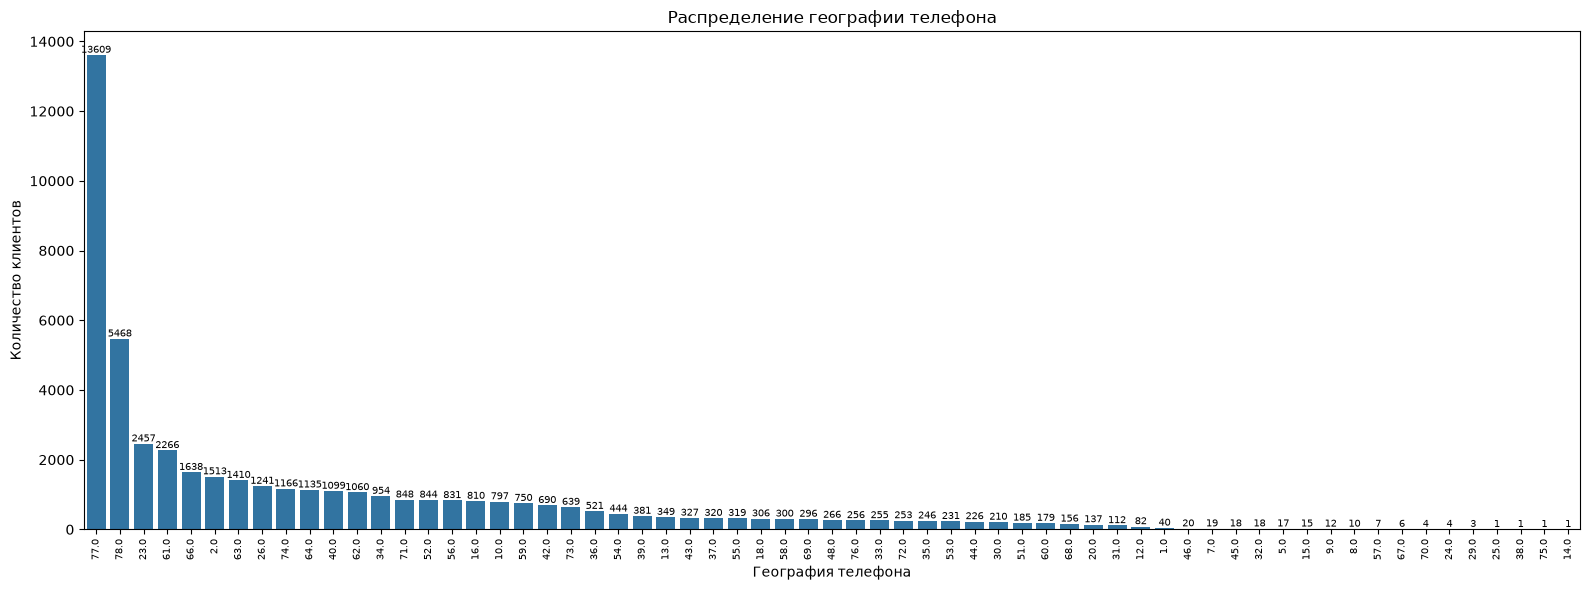

In [29]:
#посмотрим распределение по географии телефона, мы видим, что Московская область преобладает
geo_count = df['География телефона'].value_counts()

plt.figure(figsize=(16, 6))
ax = sns.barplot(x=geo_count.index.astype(str), y=geo_count.values)
ax.bar_label(ax.containers[0], fontsize=7)
plt.xticks(rotation=90, fontsize=7)
plt.title('Распределение географии телефона')
plt.xlabel('География телефона')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

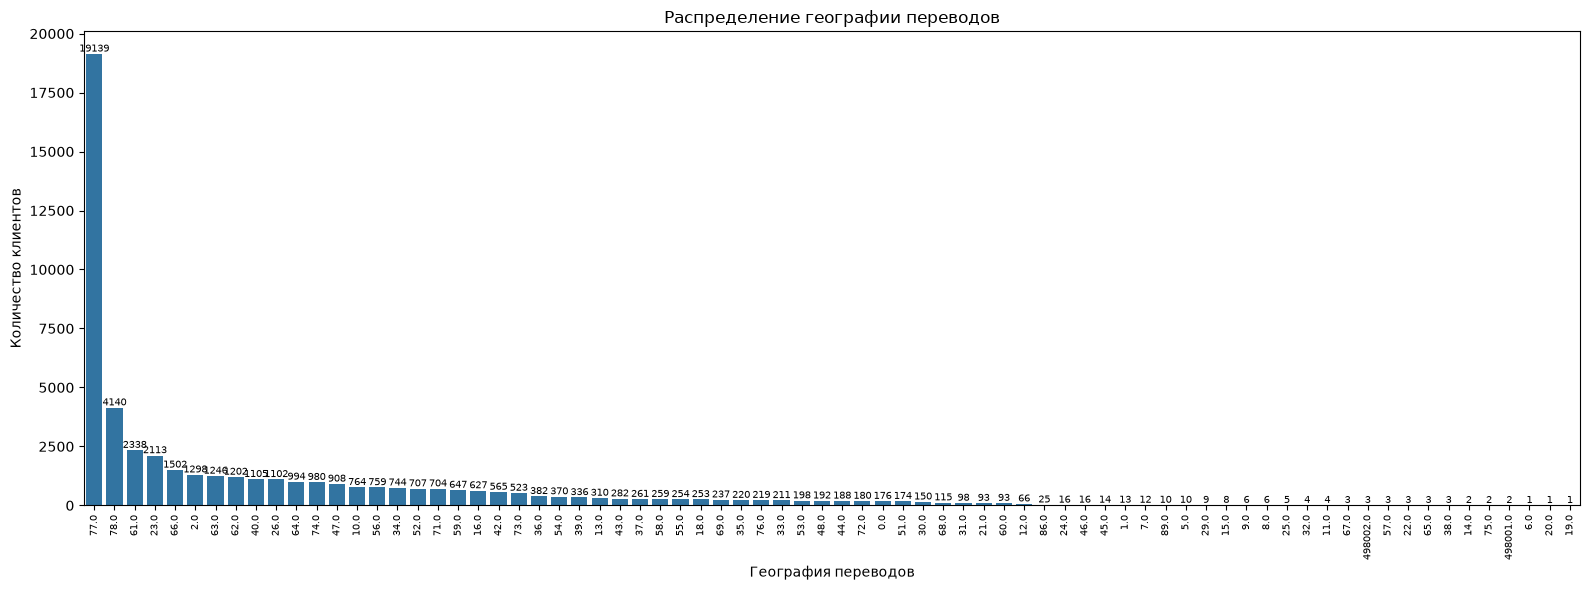

In [30]:
#посмотрим распределение по географии перевода, мы видим, что Московская область преобладает
geo_counts = df['География переводов'].value_counts()

plt.figure(figsize=(16, 6))
ax = sns.barplot(x=geo_counts.index.astype(str), y=geo_counts.values)
ax.bar_label(ax.containers[0], fontsize=7)
plt.xticks(rotation=90, fontsize=7)
plt.title('Распределение географии переводов')
plt.xlabel('География переводов')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

Делаем вывод, что по Московской области в основном переводы, значит заменяем пропуски в столбце "География телефона" на значения из столбца "География переводов"

Так же выше было выявлены в столбце "География переводов" 0 значения, их можно заменить модой, статистика не пострадает

In [31]:
# заменим значения 0 в "География переводов" на моду
mode_geo = df['География переводов'].mode()[0]

df['География переводов'] = df['География переводов'].replace(0, mode_geo) 

In [32]:
#заменяем пропущеные значения в "География телефона" на значения из "География переводов"
df['География телефона'] = df['География телефона'].fillna(df['География переводов'])

In [33]:
# проверяем кол-во 0
zero_count = (df['География переводов'] == 0).sum()
print(f"Нулей в 'География переводов': {zero_count}")

Нулей в 'География переводов': 0


In [34]:
zero = (df['География телефона'] == 0).sum()
print(f"Нулей в 'География телефона': {zero}")

Нулей в 'География телефона': 0


In [35]:
df.isnull().sum()

Идентификатор                                     0
Дата рождения                                     0
Дисциплина клиентов без просрочки по кредиту      1
Количество переводов                             26
Тип переводов                                     0
География переводов                               0
География телефона                                0
Сумма перевода                                   26
Канал, через который пришел клиент               31
Оператор связи                                  642
Пол                                               9
Возраст                                           0
dtype: int64

In [36]:
# смотрим на пропуски
df[df['Количество переводов'].isnull()]

,Идентификатор,Дата рождения,Дисциплина клиентов без просрочки по кредиту,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,"Канал, через который пришел клиент",Оператор связи,Пол,Возраст
50159,8434303,1979-05-05,BAD,NaN,1.0,77.0,77.0,NaN,Офис,Мобильные ТелеСистемы,Ж,47
50160,9657949,1974-02-15,MIDDLE,NaN,2.0,77.0,77.0,NaN,Офис,Мобильные ТелеСистемы,Ж,52
50161,12660236,1963-11-17,BAD,NaN,1.0,77.0,77.0,NaN,Офис,Мобильные ТелеСистемы,Ж,62
50162,3541321,1990-06-12,BAD,NaN,49.0,77.0,77.0,NaN,Офис,Вымпел-Коммуникации,М,36
50168,15168103,1983-07-20,MIDDLE,NaN,2.0,77.0,77.0,NaN,Офис,МегаФон,М,43
50170,16065957,1975-07-04,BAD,NaN,1.0,34.0,34.0,NaN,Офис,Волгоград-GSM,М,51
50171,15372644,1982-02-02,BAD,NaN,1.0,77.0,77.0,NaN,Офис,Мобильные ТелеСистемы,Ж,44
50172,12413061,1982-06-15,MIDDLE,NaN,1.0,77.0,77.0,NaN,Офис,МегаФон,М,44
50173,10235326,1977-01-22,BAD,NaN,2.0,77.0,77.0,NaN,Офис,МегаФон,Ж,49
50176,17282066,1980-02-15,BAD,NaN,2.0,77.0,71.0,NaN,Партнер,Вотек Мобайл,М,46


In [37]:
#принимаю решения пропуски удалить по столбцам "Дисциплина клиентов без просрочки по кредиту", 
# "Количество переводов", "Сумма перевода", "Пол". На статистику это не повлияет,
#  данных мало и две колонки по пропускам совпадают "Количество переводов" и "Сумма перевода" 
# всего 36 записи

df = (df.dropna(subset=['Дисциплина клиентов без просрочки по кредиту', 
                       'Количество переводов', 'Сумма перевода', 'Пол']))

In [38]:
# столбец "Канал, через который пришел клиент" можно заполнить модой, мало данных, на статистику не повляет
mode_channel = df['Канал, через который пришел клиент'].mode()[0]

# Заполняем пропуски
df['Канал, через который пришел клиент'] = df['Канал, через который пришел клиент'].fillna(mode_channel)

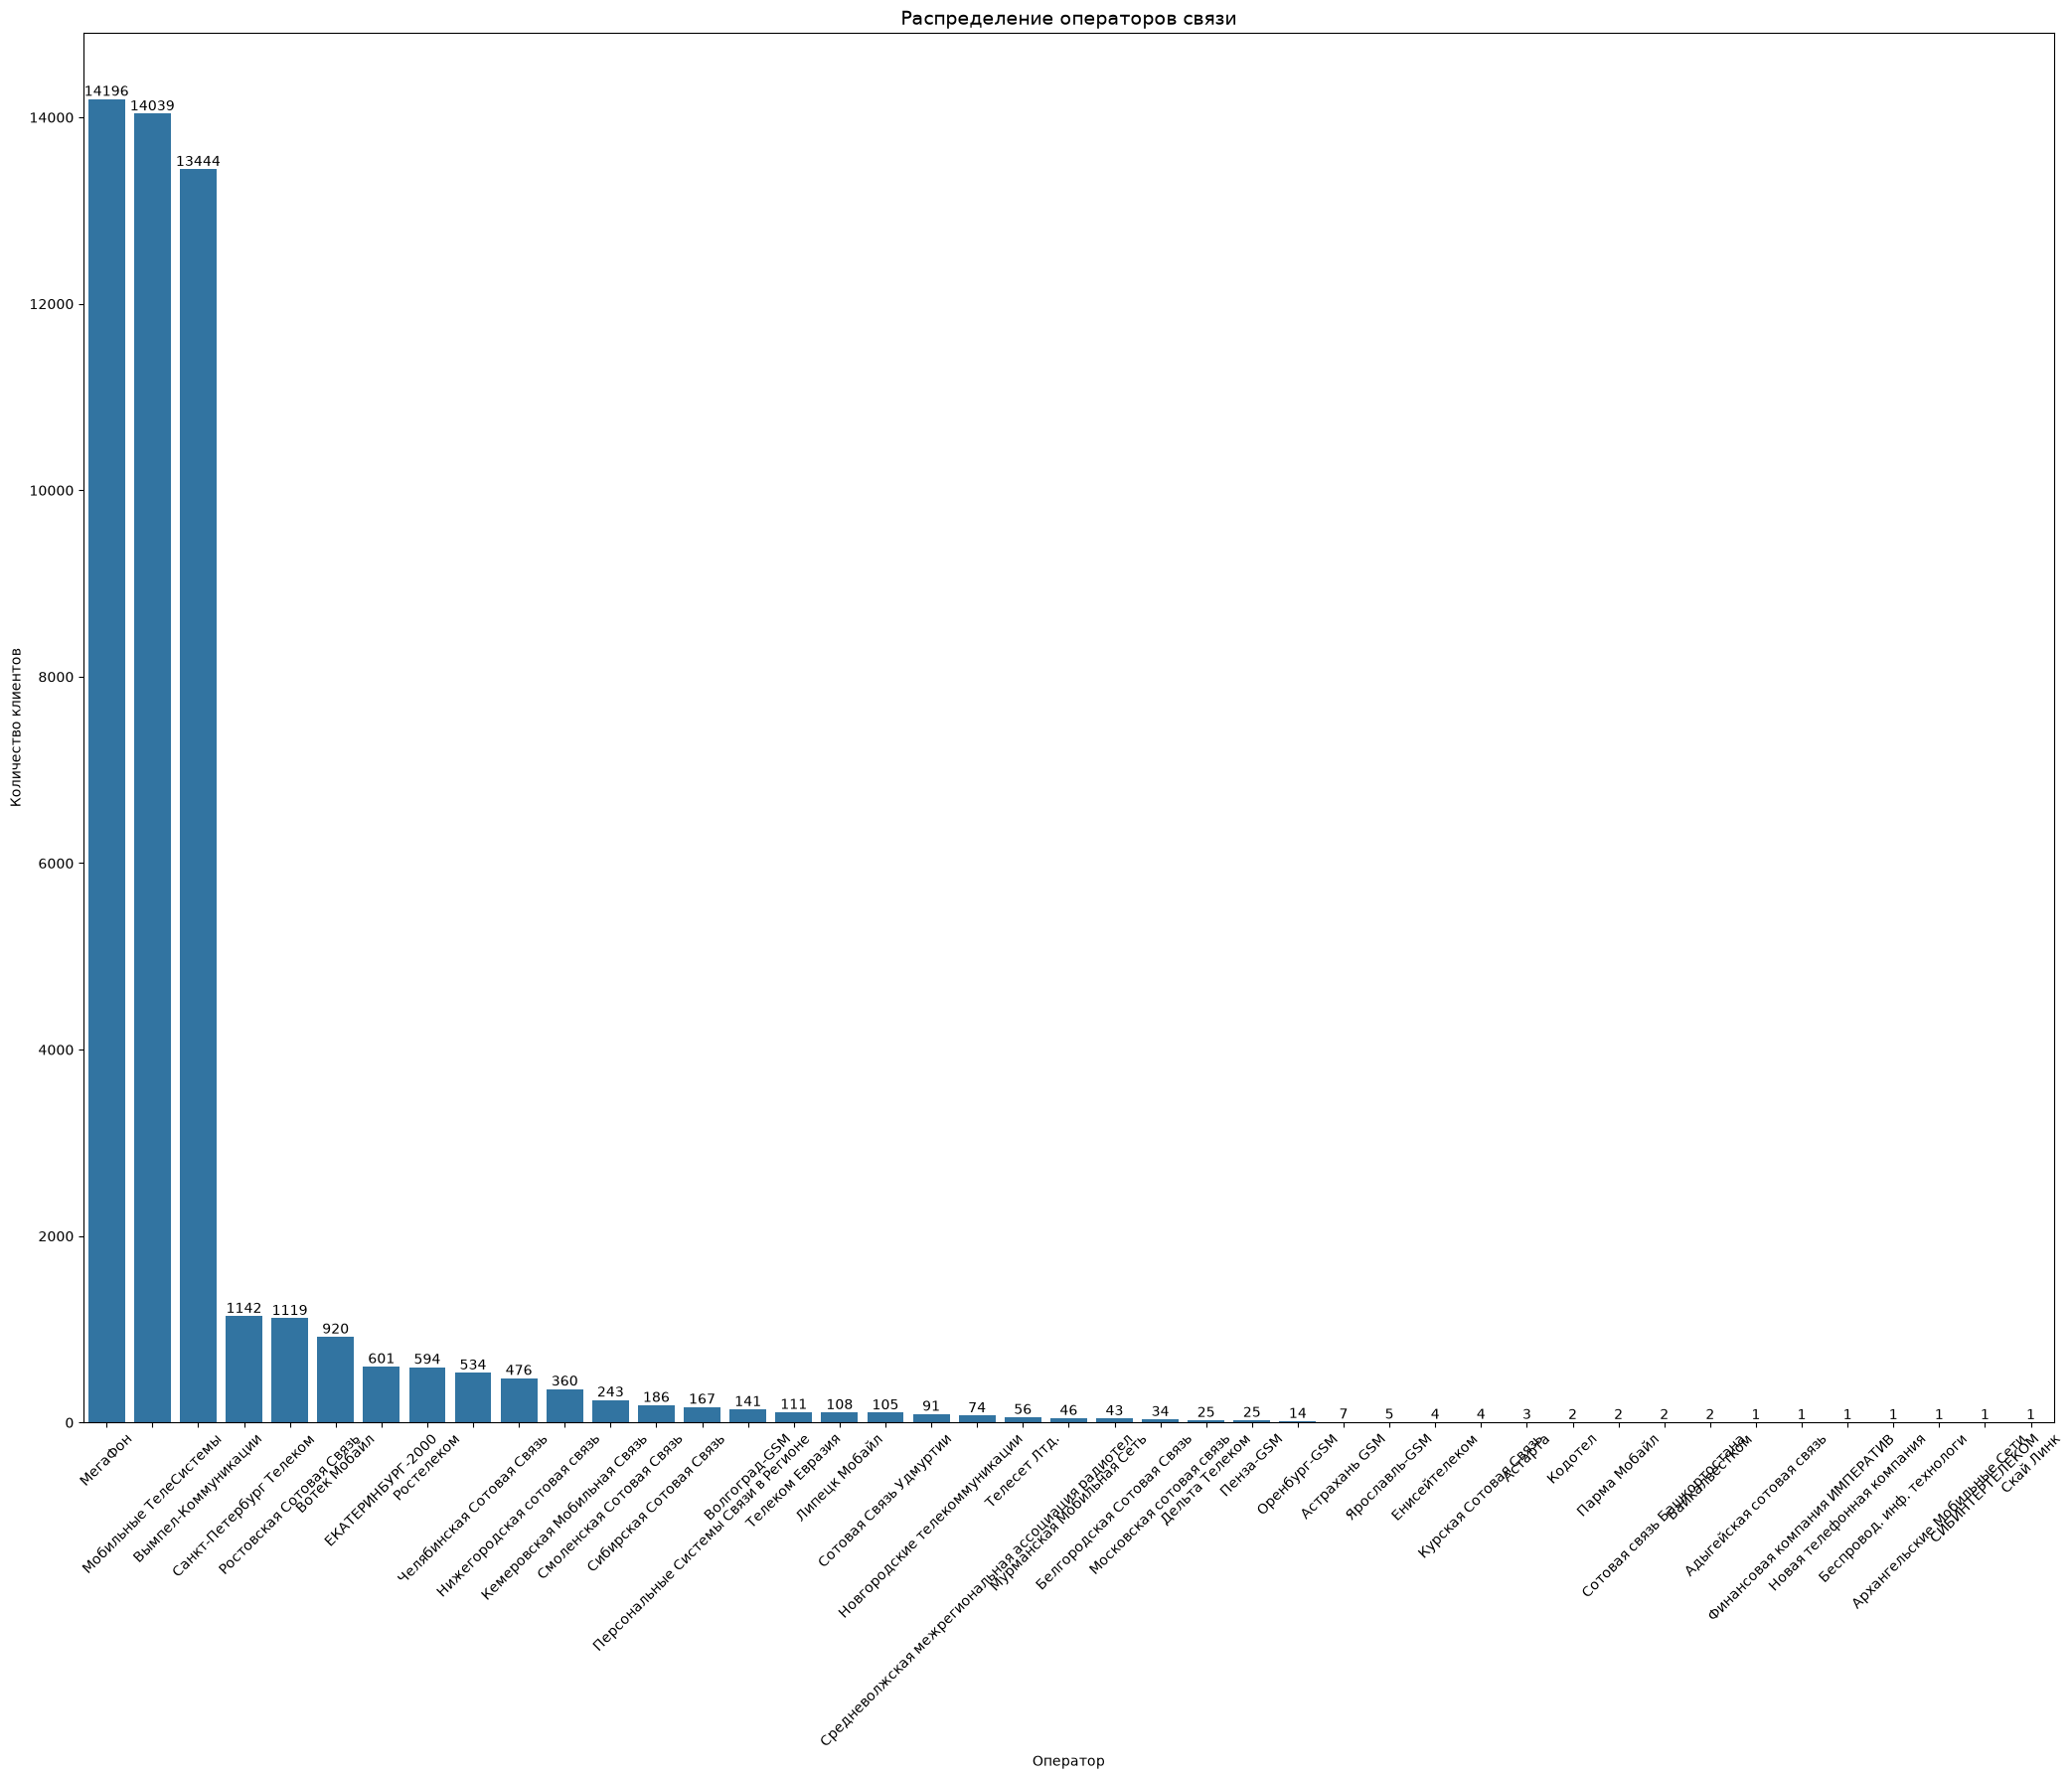

In [39]:
#посмотрим распределение по операторам связи и выдеим топ-3 (в нашем случае)
operator_counts = df['Оператор связи'].value_counts()

plt.figure(figsize=(21, 18))
ax = sns.barplot(x=operator_counts.index, y=operator_counts.values)
ax.bar_label(ax.containers[0], fontsize=10)  # подписи значений

plt.title('Распределение операторов связи', fontsize=14)
plt.xlabel('Оператор')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
# Можно выделить ТОП-3 оператора связи, остальные объединить 
# и заполнить пропуски модой, как мы видим на статистику не повлияет

mode_operator = df['Оператор связи'].mode()[0]

# Заполняем пропуски
df['Оператор связи'] = df['Оператор связи'].fillna(mode_operator)

In [41]:
df.isnull().sum()

Идентификатор                                   0
Дата рождения                                   0
Дисциплина клиентов без просрочки по кредиту    0
Количество переводов                            0
Тип переводов                                   0
География переводов                             0
География телефона                              0
Сумма перевода                                  0
Канал, через который пришел клиент              0
Оператор связи                                  0
Пол                                             0
Возраст                                         0
dtype: int64

In [42]:
# пропущеных значений нет, заеняем тип данных в категориальных данных
df = df.astype({'География переводов': 'int',
                'Тип переводов': 'int',
                'География телефона': 'int'})

In [43]:
#проверим сколько записей в типе переводов, содержащих значение -1
df[df['Тип переводов'] == -1]


,Идентификатор,Дата рождения,Дисциплина клиентов без просрочки по кредиту,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,"Канал, через который пришел клиент",Оператор связи,Пол,Возраст
18826,4570392,1974-10-07,GOOD,9.0,-1,77,74,385396.0,Стойка,Мобильные ТелеСистемы,М,51


In [44]:
#так как тип перевода, содержит одну запись со значением -1 
# скорее всего это ошибка и переведем в 1
df['Тип переводов'] = df['Тип переводов'].replace(-1, 1)

In [45]:
# география переводов 5 значений с аномальными значениями, похоже на телефонный код Московской области 498
# заменим на 77 регион
df.nlargest(10, 'География переводов')

,Идентификатор,Дата рождения,Дисциплина клиентов без просрочки по кредиту,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,"Канал, через который пришел клиент",Оператор связи,Пол,Возраст
769,2682337,1987-05-26,MIDDLE,3.0,2,498002,40,59303.45,Офис,МегаФон,Ж,39
15690,10568823,1981-05-16,BAD,3.0,2,498002,77,440162.00,Партнер,Вымпел-Коммуникации,М,45
22371,12253054,1970-02-02,GOOD,12.0,2,498002,77,215512.25,Офис,МегаФон,Ж,56
28308,7390416,1970-01-12,MIDDLE,7.0,2,498001,63,190600.00,Партнер,Мобильные ТелеСистемы,Ж,56
33697,3651661,1958-10-27,MIDDLE,10.0,2,498001,23,121745.51,Партнер,МегаФон,М,67
154,9872066,1979-06-20,BAD,9.0,5,89,2,103000.00,Партнер,МегаФон,М,47
5942,18179915,1980-03-27,GOOD,14.0,2,89,72,655890.00,Стойка,МегаФон,Ж,46
18531,13659527,1956-11-25,MIDDLE,7.0,5,89,26,231915.67,Стойка,Мобильные ТелеСистемы,Ж,69
18678,6676795,1945-02-23,GOOD,8.0,6,89,26,153782.00,Партнер,МегаФон,Ж,81
19477,4576200,1956-12-04,GOOD,47.0,2,89,72,187950.00,Партнер,Мобильные ТелеСистемы,М,69


In [46]:
# заменяем регион
df['География переводов'] = df['География переводов'].replace([498001.0, 498002.0], 77)

In [47]:
df.describe()

,Идентификатор,Дата рождения,Количество переводов,Тип переводов,География переводов,География телефона,Сумма перевода,Возраст
count,4.957300e+04,49573,49573.000000,49573.000000,49573.000000,49573.000000,4.957300e+04,49573.000000
mean,1.097086e+07,1970-08-29 19:15:12.762000,15.873762,13.254957,60.759405,58.488310,2.940987e+05,55.567809
min,1.400402e+06,1940-01-20 00:00:00,1.000000,1.000000,1.000000,1.000000,3.000000e+01,34.000000
25%,6.375858e+06,1962-04-27 00:00:00,4.000000,2.000000,48.000000,42.000000,9.137500e+04,47.000000
50%,1.133641e+07,1971-04-28 00:00:00,9.000000,5.000000,73.000000,66.000000,1.857000e+05,55.000000
75%,1.444320e+07,1979-06-27 00:00:00,17.000000,6.000000,77.000000,77.000000,3.759580e+05,64.000000
max,3.006527e+07,1991-09-20 00:00:00,2220.000000,69.000000,89.000000,78.000000,1.953691e+07,86.000000
std,5.764206e+06,NaN,29.575325,22.333318,21.698382,22.527097,4.467058e+05,10.884182


In [48]:
#делаем вывод вместе с дублями было удалено 651 запись - это 1,31% потери(минимальный).Данные сохранили максимально.
df.info()

<class 'pandas.DataFrame'>
Index: 49573 entries, 0 to 50157
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   Идентификатор                                 49573 non-null  int64         
 1   Дата рождения                                 49573 non-null  datetime64[ms]
 2   Дисциплина клиентов без просрочки по кредиту  49573 non-null  str           
 3   Количество переводов                          49573 non-null  float64       
 4   Тип переводов                                 49573 non-null  int64         
 5   География переводов                           49573 non-null  int64         
 6   География телефона                            49573 non-null  int64         
 7   Сумма перевода                                49573 non-null  float64       
 8   Канал, через который пришел клиент            49573 non-null  str           
 9   

- Исследовательский анализ данных

In [49]:
#- в разрезе значений целевого признака (`Дисциплина клиентов без просрочки по кредиту`)
#  исследовать распределения числовых и категориальных признаков;
# посмотрим на группы

sign = 'Дисциплина клиентов без просрочки по кредиту'
print(df[sign].value_counts())

Дисциплина клиентов без просрочки по кредиту
GOOD      26843
MIDDLE    13529
BAD        9201
Name: count, dtype: int64


Выделим, что клиенты с дисциплиной GOOD перобладают, платежеспособные

In [ ]:
# в процентном соотношении нагляднее, какой процент у каждой дисциплины
print((df[sign].value_counts(normalize=True) * 100).round(2))


Дисциплина клиентов без просрочки по кредиту
GOOD      54.15
MIDDLE    27.29
BAD       18.56
Name: proportion, dtype: float64


In [ ]:
# поделим на группы, чтобы исследовать категориальные признаки и количественные признаки
df_good = df[df[sign] == 'GOOD']
df_middle = df[df[sign] == 'MIDDLE']
df_bad = df[df[sign] == 'BAD']

C:\Users\семейство Елисеевых\AppData\Local\Temp\ipykernel_1808\1392013981.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=sign, y='Возраст', palette='Set2')


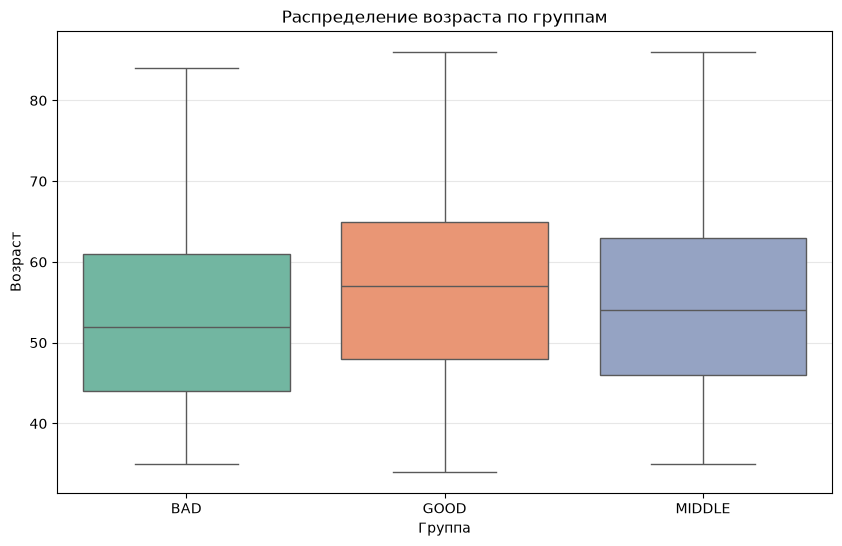

In [ ]:
# Посмотрим минимальные и максимальные значения возраста в разрезе групп дисциплины
# так же посмотрим насколько отличаются показатели среднего и медианного возраста 
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=sign, y='Возраст', palette='Set2')
plt.title('Распределение возраста по группам')
plt.xlabel('Группа')
plt.ylabel('Возраст')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [67]:
grouped = df.groupby(sign)['Возраст']

boxplot_stats = pd.DataFrame({'min': grouped.min(),
                               'q1': grouped.quantile(0.25),
                           'median': grouped.median(),
                             'mean': grouped.mean(),
                               'q3': grouped.quantile(0.75),
                              'max': grouped.max()}).round(1)

print(boxplot_stats)

                                              min    q1  median  mean    q3  \
Дисциплина клиентов без просрочки по кредиту                                  
BAD                                            35  44.0    52.0  53.1  61.0   
GOOD                                           34  48.0    57.0  56.9  65.0   
MIDDLE                                         35  46.0    54.0  54.5  63.0   

                                              max  
Дисциплина клиентов без просрочки по кредиту       
BAD                                            84  
GOOD                                           86  
MIDDLE                                         86  


Распределение возраста во всех группах близко к нормальному:  
среднее и медиана практически совпадают, резких скачков не наблюдается.  
Возраст клиентов распределён равномерно, без сильных перекосов.

- возраст в среднем от 44-65
- в дисциплине GOOD более старшее поколение от 48 до 65
- в дисциплине BAD более старшее поколение от 44 до 61
- в дисциплине MIDDLE более старшее поколение от 46 до 63

Пол                                               Ж      М
Дисциплина клиентов без просрочки по кредиту              
BAD                                            4464   4737
GOOD                                          13856  12987
MIDDLE                                         6863   6666
Пол                                              Ж     М
Дисциплина клиентов без просрочки по кредиту            
BAD                                           48.5  51.5
GOOD                                          51.6  48.4
MIDDLE                                        50.7  49.3


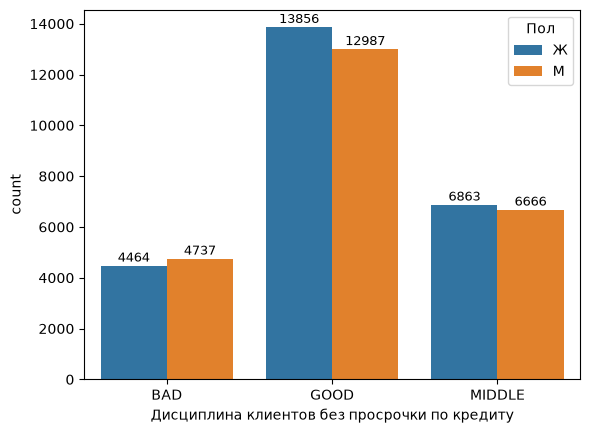

In [73]:
cross_tab = pd.crosstab(df['Дисциплина клиентов без просрочки по кредиту'], df['Пол'])
cross_percent = pd.crosstab(df['Дисциплина клиентов без просрочки по кредиту'], df['Пол'], normalize='index') * 100

print(cross_tab)
print(cross_percent.round(1))

# график
ax = sns.countplot(data=df, x=sign, hue='Пол')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=1)
plt.show()

Женщин больше в дисциплине GOOD 
Мужчин больше в дисциплине BAD
в дисциплине MIDDLE Ж и М по кол-ву почти одинаково, но Ж больше

Дисциплина клиентов без просрочки по кредиту   BAD  GOOD  MIDDLE
Канал, через который пришел клиент                              
Офис                                          40.0  55.0    47.0
Партнер                                       50.0  37.0    44.0
Стойка                                        10.0   8.0     9.0


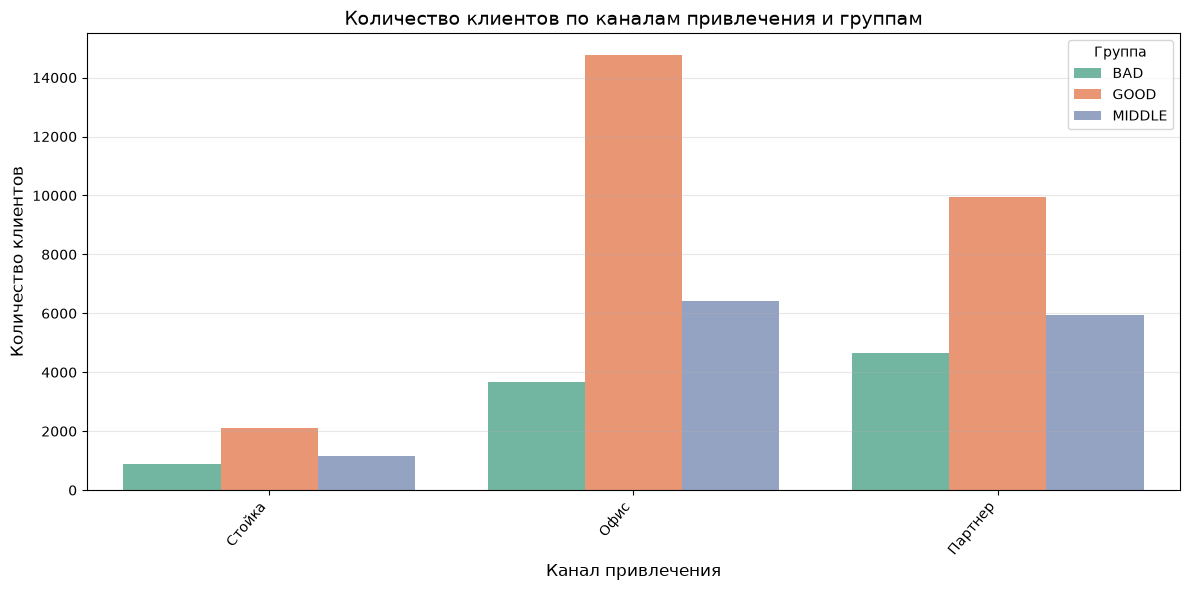

In [74]:
# Посмотрим по каким каналам привлечение клиентов больше

print(pd.crosstab(df['Канал, через который пришел клиент'], 
                  df['Дисциплина клиентов без просрочки по кредиту'], 
                  normalize='columns').round(2) * 100)

# график
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Канал, через который пришел клиент', hue=sign, palette='Set2')
plt.title('Количество клиентов по каналам привлечения и группам', fontsize=14)
plt.xlabel('Канал привлечения', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.legend(title='Группа')
plt.xticks(rotation=50, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

В основном клиенты приходят через офис или партнера(на втором месте), очень мало через стойку
в процентном соотношении мы видим, что через партнера пришли клиенты с дисциплиной BAD
клиенты с дисциплиной GOOD пришли в основном через офис
клиенты с дисциплиной MIDDLE пришли почти поровну через партнера и через офис, но через офис больше

Офис — основной канал привлечения клиентов

Партнёр — второй по значимости канал

Стойка — используется редко, доля минимальна (<10%)

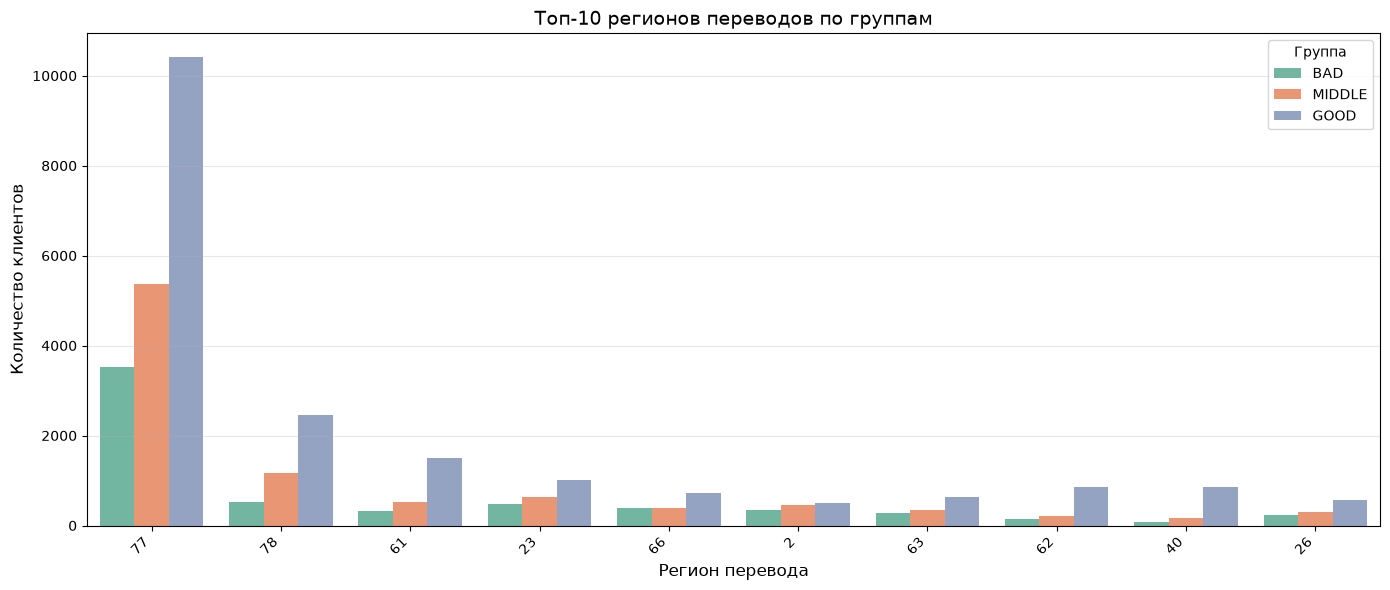

In [75]:
# Посмотрим распределение региона перевода. Находим топ-10 регионов перевода
top_geo_transfer = df['География переводов'].value_counts().head(10).index
df_top_transfer = df[df['География переводов'].isin(top_geo_transfer)]

# 2. Строим график
plt.figure(figsize=(14, 6))
sns.countplot(data=df_top_transfer, 
              x='География переводов', 
              hue=sign, 
              palette='Set2',
              order=top_geo_transfer)  # сортировка по убыванию
plt.title('Топ-10 регионов переводов по группам', fontsize=14)
plt.xlabel('Регион перевода', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.legend(title='Группа')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

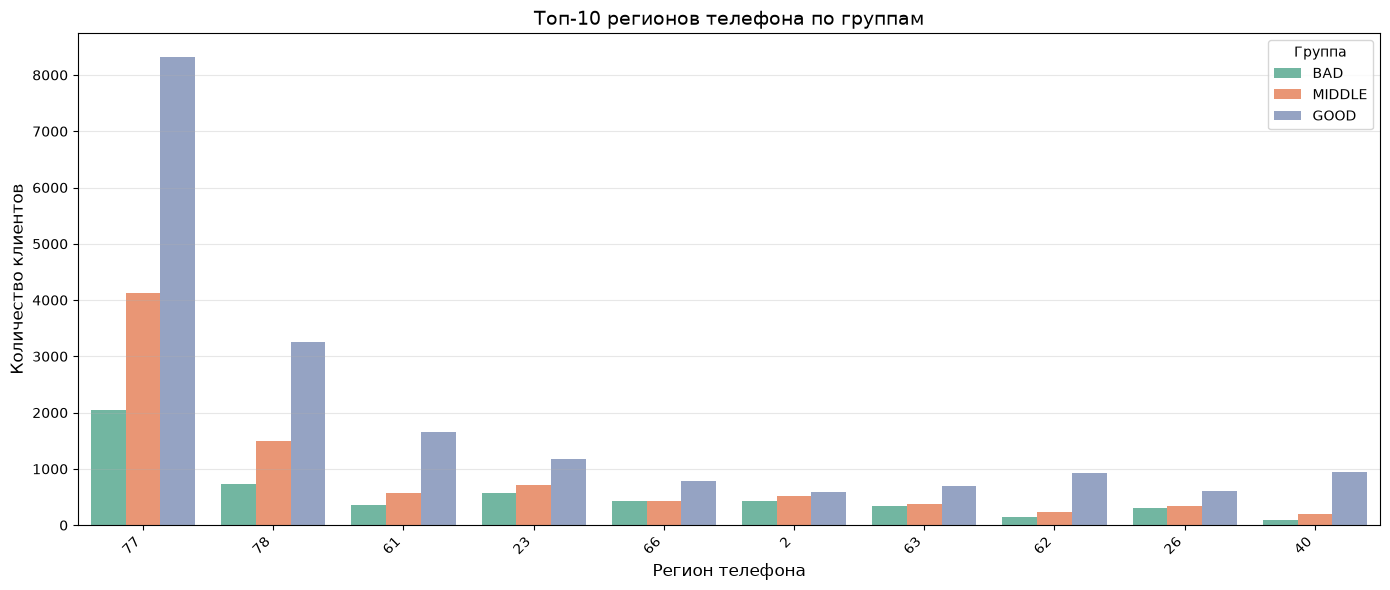

In [76]:
#  Посмотрим распределение географию телефона. Находим топ-10 регионов телефона
top_geo_phone = df['География телефона'].value_counts().head(10).index
df_top_phone = df[df['География телефона'].isin(top_geo_phone)]

# 2. Строим график
plt.figure(figsize=(14, 6))
sns.countplot(data=df_top_phone, 
              x='География телефона', 
              hue=sign, 
              palette='Set2',
              order=top_geo_phone)
plt.title('Топ-10 регионов телефона по группам', fontsize=14)
plt.xlabel('Регион телефона', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.legend(title='Группа')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Наглядно видно, что переводами пользуются клиенты из региона 77, на 2 месте клиенты из 78 региона и на 3-м месте из 61 региона. кол-во клиентов из дисциплины GOOD  в каждом регионе больше (платёжеспособные клиенты активнее пользуются переводами независимо от региона)

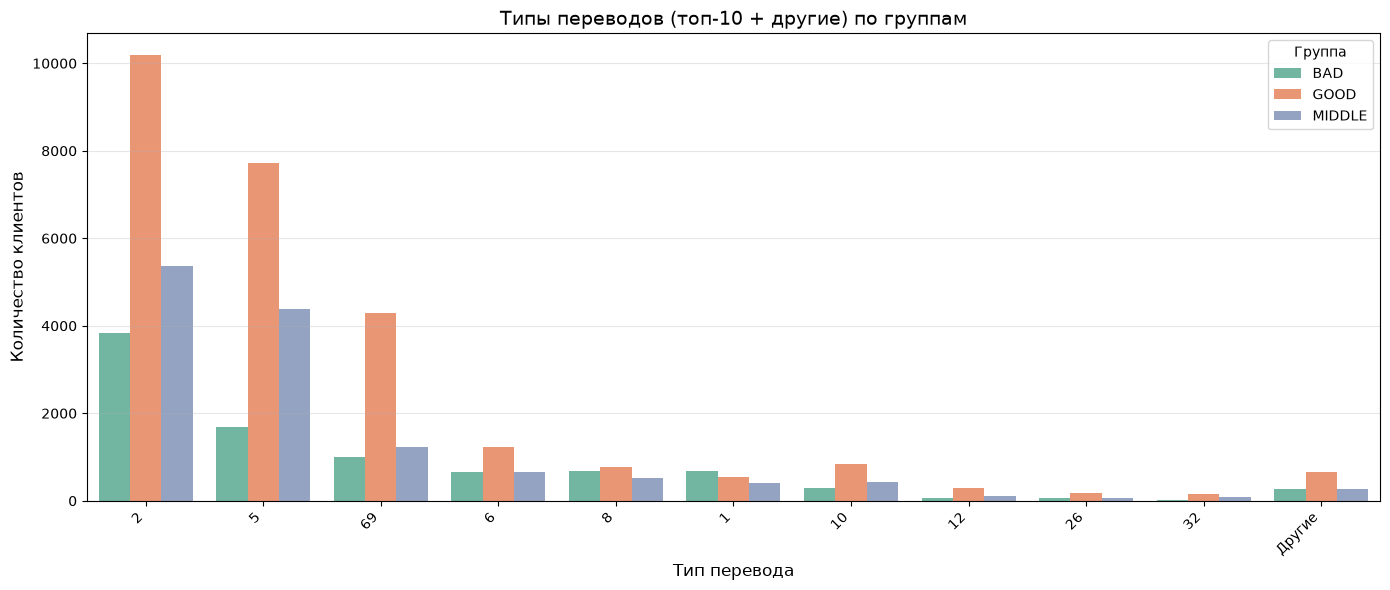

In [77]:
# Посмотрим распределение по типу переводов. Группировка топ-10 + Другие
top_types = df['Тип переводов'].value_counts().head(10).index
df['Тип_группа'] = df['Тип переводов'].apply(lambda x: x if x in top_types else 'Другие')

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='Тип_группа', hue=sign, palette='Set2',
              order=top_types.tolist() + ['Другие'])
plt.title('Типы переводов (топ-10 + другие) по группам', fontsize=14)
plt.xlabel('Тип перевода', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.legend(title='Группа')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [83]:
# Проверка типа 1
df_type1 = df[df['Тип переводов'] == 1]
print(df_type1['Дисциплина клиентов без просрочки по кредиту'].value_counts(normalize=True) * 100)

Дисциплина клиентов без просрочки по кредиту
BAD       41.415385
GOOD      33.046154
MIDDLE    25.538462
Name: proportion, dtype: float64


Можно выделить топ 3 основных типов перевода -2, 5, 69
Так же с дисциплиной GOOD клиенты преобладают,
но по типу перевода 1 клиенты с дисциплиной BAD пользуются чаще 

Типы переводов 2, 5 и 69 характерны для платёжеспособных клиентов, тогда как тип 1 может рассматриваться как потенциальный маркер неблагоприятной платёжной дисциплины

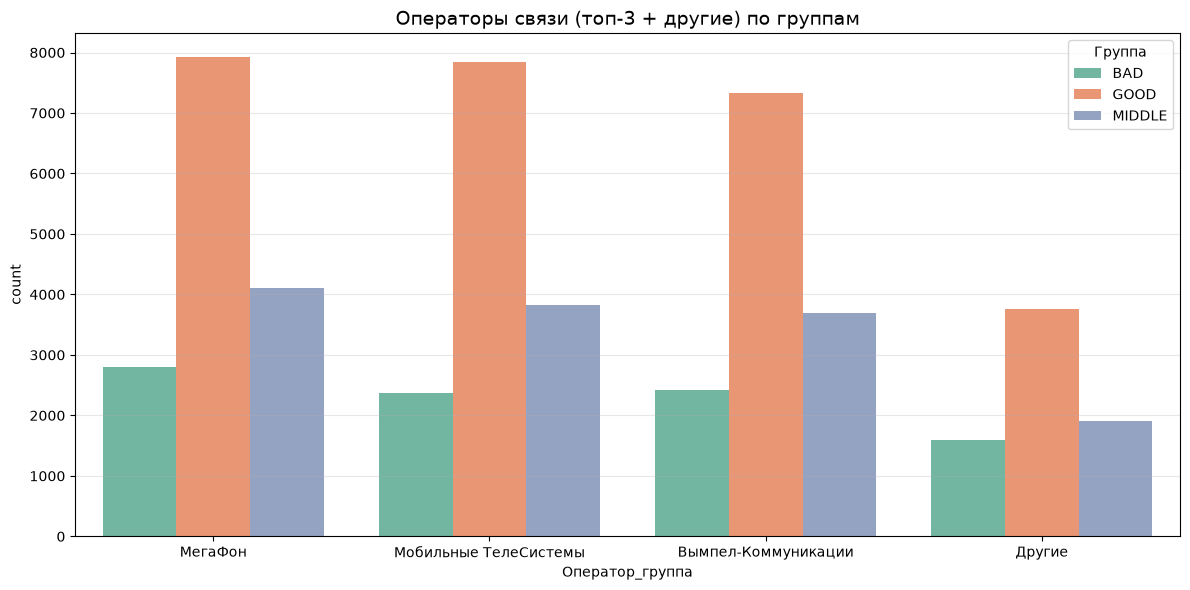

In [91]:
# Проверим распределение по операторам связи. Группировка топ-3 + Другие
top_operators = df['Оператор связи'].value_counts().head(3).index
df['Оператор_группа'] = df['Оператор связи'].apply(
    lambda x: x if x in top_operators else 'Другие'
)

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Оператор_группа', hue=sign, palette='Set2',
              order=top_operators.tolist() + ['Другие'])
plt.title('Операторы связи (топ-3 + другие) по группам', fontsize=14)
plt.legend(title='Группа')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Выделим 3 топ оператора:
- Мегафон
- Мобильные телесистемы
- Вымпел-Коммуникации 
можно посмотреть как влияет мобильный оператор на географию переводов или наоборот


=== МегаФон ===
География переводов
77    48.0
78     9.4
63     4.5
61     4.3
64     2.6
Name: МегаФон, dtype: float64

=== Мобильные ТелеСистемы ===
География переводов
77    39.4
23    10.5
78     8.7
2      3.7
40     3.1
Name: Мобильные ТелеСистемы, dtype: float64

=== Вымпел-Коммуникации ===
География переводов
77    48.5
78     6.7
26     3.9
61     3.0
62     2.4
Name: Вымпел-Коммуникации, dtype: float64


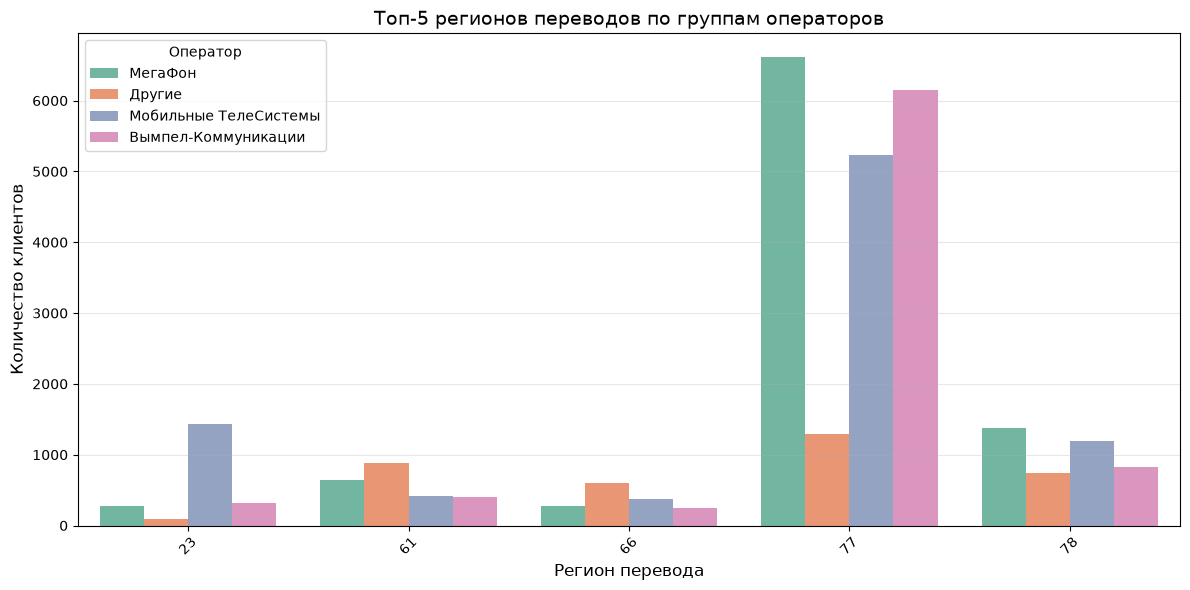

In [95]:
cross_operator_transfer = pd.crosstab(df_top['Оператор связи'], df_top['География переводов'], normalize='index') * 100

# Топ-5 регионов для каждого оператора
for op in top_operators:
    print(f"\n=== {op} ===")
    print(cross_operator_transfer.loc[op].sort_values(ascending=False).head(5).round(1))
    
top_regions = df['География переводов'].value_counts().head(5).index
df_plot = df[df['География переводов'].isin(top_regions)]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_plot, x='География переводов', hue='Оператор_группа', palette='Set2')
plt.title('Топ-5 регионов переводов по группам операторов', fontsize=14)
plt.xlabel('Регион перевода', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.legend(title='Оператор')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Мобильный оператор связан с географией переводов.  
МТС выделяется меньшей долей Москвы и ориентацией на южные регионы,  
тогда как МегаФон и Вымпел-Коммуникации сильнее привязаны к Московскому региону.

C:\Users\семейство Елисеевых\AppData\Local\Temp\ipykernel_1808\797276575.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=sign, y='Количество переводов', palette='Set2')


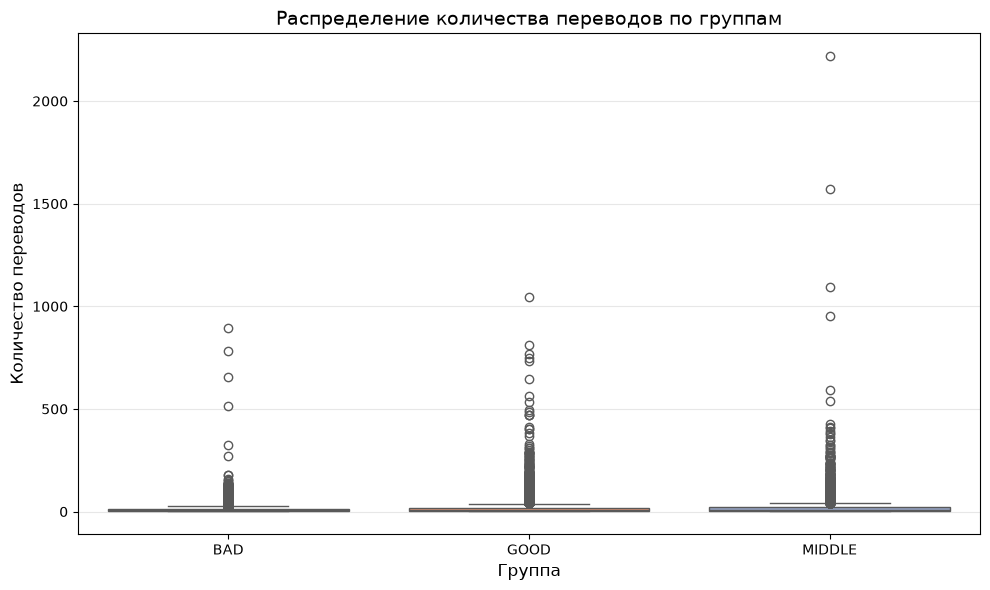

In [ ]:
# распределение кол-ва переводов по группам
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=sign, y='Количество переводов', palette='Set2')
plt.title('Распределение количества переводов по группам', fontsize=14)
plt.xlabel('Группа', fontsize=12)
plt.ylabel('Количество переводов', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\семейство Елисеевых\AppData\Local\Temp\ipykernel_1808\1432981771.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=sign, y='Сумма перевода', palette='Set2')


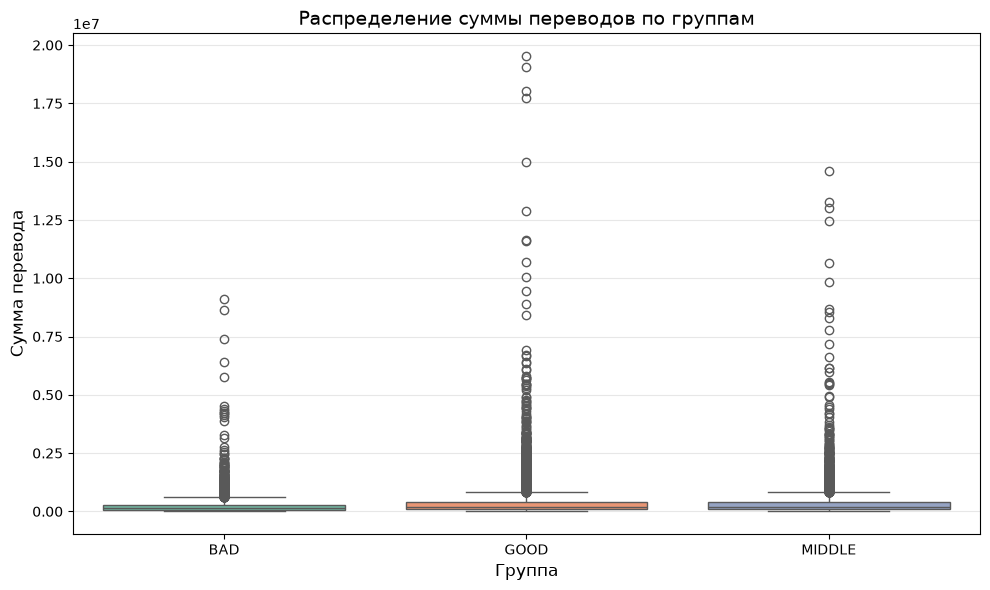

In [ ]:
# распределение суммы переводов по группам
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=sign, y='Сумма перевода', palette='Set2')
plt.title('Распределение суммы переводов по группам', fontsize=14)
plt.xlabel('Группа', fontsize=12)
plt.ylabel('Сумма перевода', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

По графикам видим - есть выбросы, раньше было исследовано - они могут быть реальными 

расчитаем для них среднее и медиану 

In [101]:
# Считаем средние по группам
group_stats = df.groupby([sign])[['Количество переводов', 'Сумма перевода']].mean().round(2)

# Считаем общую сумму средних
total_mean_count = group_stats['Количество переводов'].sum()
total_mean_sum = group_stats['Сумма перевода'].sum()

# Считаем проценты
group_stats['% от общего (кол-во)'] = (group_stats['Количество переводов'] / total_mean_count * 100).round(2)
group_stats['% от общего (сумма)'] = (group_stats['Сумма перевода'] / total_mean_sum * 100).round(2)

print(group_stats)

                                              Количество переводов  \
Дисциплина клиентов без просрочки по кредиту                         
BAD                                                          10.82   
GOOD                                                         16.34   
MIDDLE                                                       18.38   

                                              Сумма перевода  \
Дисциплина клиентов без просрочки по кредиту                   
BAD                                                228328.04   
GOOD                                               311351.93   
MIDDLE                                             304596.64   

                                              % от общего (кол-во)  \
Дисциплина клиентов без просрочки по кредиту                         
BAD                                                          23.76   
GOOD                                                         35.88   
MIDDLE                                          

In [112]:
# Считаем медианы
median_count = df.groupby([sign])['Количество переводов'].median()
median_sum = df.groupby([sign])['Сумма перевода'].median()

# Считаем проценты
print('МЕДИАНА КОЛИЧЕСТВА ПЕРЕВОДОВ (в %)')
print((median_count / median_count.sum() * 100).round(2))

print('\nМЕДИАНА СУММЫ ПЕРЕВОДОВ (в %)')
print((median_sum / median_sum.sum() * 100).round(2))
print(df.groupby([sign])['Сумма перевода'].median())


МЕДИАНА КОЛИЧЕСТВА ПЕРЕВОДОВ (в %)
Дисциплина клиентов без просрочки по кредиту
BAD       24.0
GOOD      36.0
MIDDLE    40.0
Name: Количество переводов, dtype: float64

МЕДИАНА СУММЫ ПЕРЕВОДОВ (в %)
Дисциплина клиентов без просрочки по кредиту
BAD       26.41
GOOD      37.78
MIDDLE    35.81
Name: Сумма перевода, dtype: float64
Дисциплина клиентов без просрочки по кредиту
BAD       139945.00
GOOD      200166.15
MIDDLE    189700.00
Name: Сумма перевода, dtype: float64


 В ходе анализа было установлено, что количественные признаки содержат выбросы (аномалии). Исключение этих значений не производилось, так как их удаление могло бы исказить реальную картину.

В связи с этим для оценки центральной тенденции выбрана медиана, которая устойчива к выбросам и даёт более репрезентативную оценку «типичного» значения, чем среднее арифметическое.


C:\Users\семейство Елисеевых\AppData\Local\Temp\ipykernel_1808\1596654557.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=median_count, x=sign, y='Количество переводов', palette='Set2')


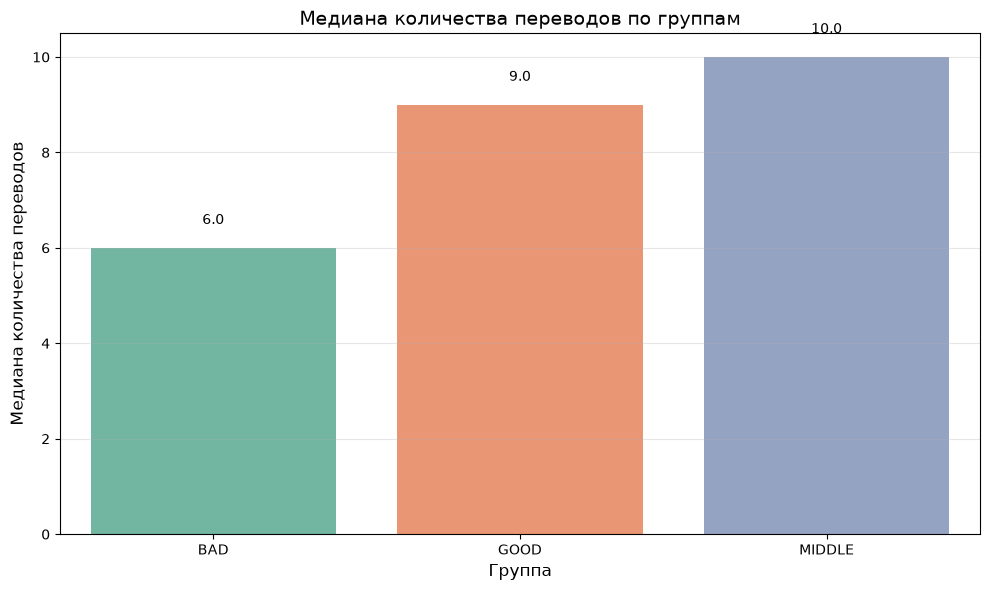

In [115]:
median_count = df.groupby([sign])['Количество переводов'].median().reset_index()

# график
plt.figure(figsize=(10, 6))
sns.barplot(data=median_count, x=sign, y='Количество переводов', palette='Set2')
plt.title('Медиана количества переводов по группам', fontsize=14)
plt.xlabel('Группа', fontsize=12)
plt.ylabel('Медиана количества переводов', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(median_count['Количество переводов']):
    plt.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\семейство Елисеевых\AppData\Local\Temp\ipykernel_1808\749439169.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=median_sum, x=sign, y='Сумма перевода', palette='Set2')


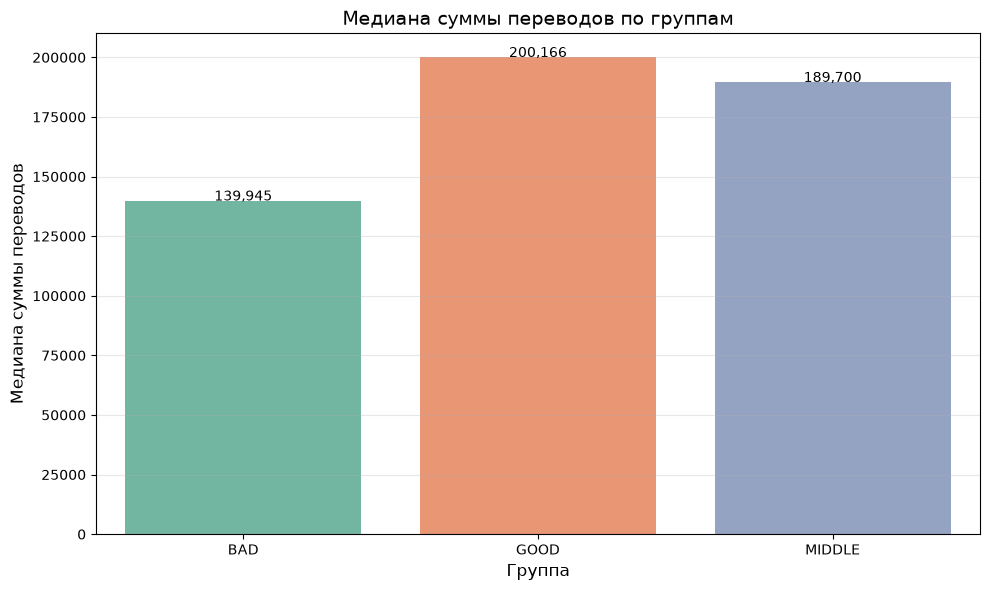

In [116]:

median_sum = df.groupby([sign])['Сумма перевода'].median().reset_index()

# график
plt.figure(figsize=(10, 6))
sns.barplot(data=median_sum, x=sign, y='Сумма перевода', palette='Set2')
plt.title('Медиана суммы переводов по группам', fontsize=14)
plt.xlabel('Группа', fontsize=12)
plt.ylabel('Медиана суммы переводов', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(median_sum['Сумма перевода']):
    plt.text(i, v + 0.5, f'{v:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Клиенты MIDDLE совершают больше переводов, но GOOD переводят большие суммы.

Это может говорить о том, что:

GOOD — более платёжеспособные клиенты (крупные суммы)

MIDDLE — активные, но с меньшими суммами

BAD — наименее активны и с наименьшими суммами

In [ ]:
# посмотрим среднее значения и медиану по полу
summary_gender = df.groupby('Пол').agg(
    count=('Пол', 'count'),
    median_count=('Количество переводов', 'median'),
    mean_count=('Количество переводов', 'mean'),
    median_sum=('Сумма перевода', 'median'),
    mean_sum=('Сумма перевода', 'mean')
).round(2)

print(summary_gender)

     count  median_count  mean_count  median_sum   mean_sum
Пол                                                        
Ж    25183           9.0       16.06    172600.0  272690.00
М    24390           8.0       15.68    200000.0  316203.44


C:\Users\семейство Елисеевых\AppData\Local\Temp\ipykernel_1808\653086773.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Пол', y='Количество переводов', palette='Set2', ax=axes[0])
C:\Users\семейство Елисеевых\AppData\Local\Temp\ipykernel_1808\653086773.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Пол', y='Сумма перевода', palette='Set2', ax=axes[1])


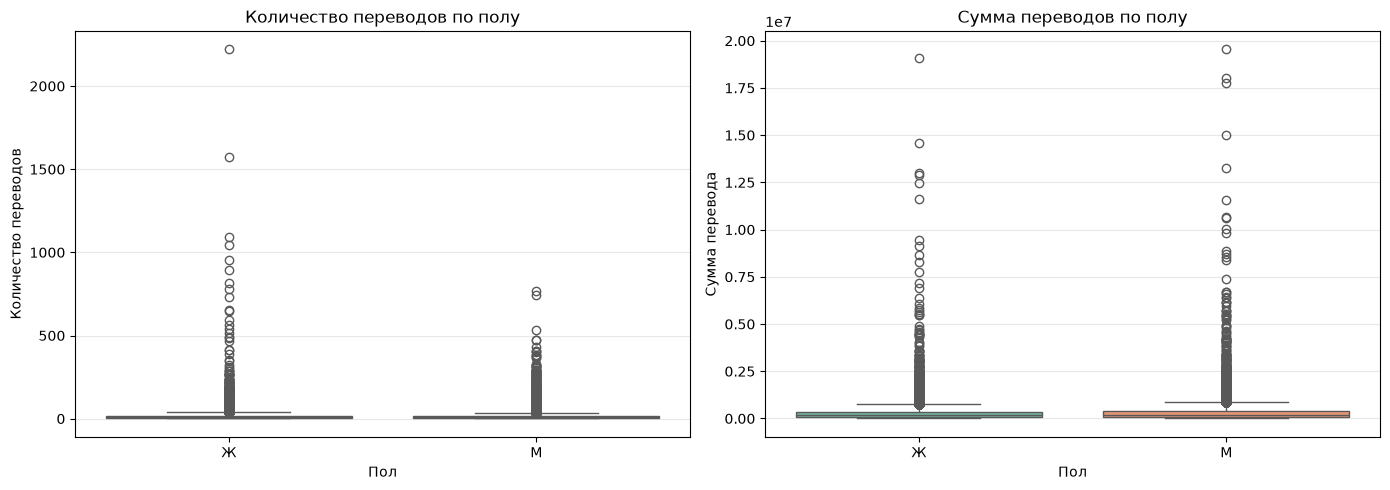

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Количество переводов
sns.boxplot(data=df, x='Пол', y='Количество переводов', palette='Set2', ax=axes[0])
axes[0].set_title('Количество переводов по полу')
axes[0].set_ylabel('Количество переводов')
axes[0].grid(axis='y', alpha=0.3)

# Сумма переводов
sns.boxplot(data=df, x='Пол', y='Сумма перевода', palette='Set2', ax=axes[1])
axes[1].set_title('Сумма переводов по полу')
axes[1].set_ylabel('Сумма перевода')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Женщины совершают переводы чаще, но на меньшие суммы.  
Мужчины переводят реже, но крупнее.  



In [138]:
from scipy import stats


# Данные
female_sum = df[df['Пол'] == 'Ж']['Сумма перевода'].dropna()
male_sum = df[df['Пол'] == 'М']['Сумма перевода'].dropna()

# Одновыборочный тест (сравнение с нормальным распределением)
# Нормализуем данные (стандартизация)
female_norm = (female_sum - female_sum.mean()) / female_sum.std()
male_norm = (male_sum - male_sum.mean()) / male_sum.std()

# Тест Колмогорова-Смирнова
stat_f, p_f = stats.kstest(female_norm, 'norm')
stat_m, p_m = stats.kstest(male_norm, 'norm')

print('ПРОВЕРКА НОРМАЛЬНОСТИ (КРИТЕРИЙ КОЛМОГОРОВА-СМИРНОВА)')
print(f"Женщины: статистика = {stat_f}, p = {p_f} → {'нормальное' if p_f > 0.05 else 'НЕ нормальное'}")
print(f"Мужчины: статистика = {stat_m}, p = {p_m} → {'нормальное' if p_m > 0.05 else 'НЕ нормальное'}")



ПРОВЕРКА НОРМАЛЬНОСТИ (КРИТЕРИЙ КОЛМОГОРОВА-СМИРНОВА)
Женщины: статистика = 0.2615545149076646, p = 0.0 → НЕ нормальное
Мужчины: статистика = 0.26381788602570555, p = 0.0 → НЕ нормальное


Распределение не нормальное → используем Манна–Уитни


In [ ]:
from scipy.stats import mannwhitneyu

# проверка гипотезы о различии между группами 
stat, p = mannwhitneyu(female_sum, male_sum, alternative='two-sided')

print('\nМанн Уитни (СУММА ПЕРЕВОДОВ)')
print(f'U-статистика: {stat:.4f}')
print(f"p-value: {p:.4f}")

if p < 0.05:
    print('Различия статистически значимы (p < 0.05)')
else:
    print('Различия не значимы (p >= 0.05)')


Манн Уитни (СУММА ПЕРЕВОДОВ)
U-статистика: 282127271.5000
p-value: 0.0000
Различия статистически значимы (p < 0.05)


Мужчины и женщины значимо различаются по сумме переводов (p < 0.001).  
Мужчины переводят крупнее, женщины — чаще, но мельче.

In [146]:
female_count = df[df['Пол'] == 'Ж']['Количество переводов'].dropna()
male_count = df[df['Пол'] == 'М']['Количество переводов'].dropna()

# Нормализация (для одновыборочного теста)
female_norm = (female_count - female_count.mean()) / female_count.std()
male_norm = (male_count - male_count.mean()) / male_count.std()

# Одновыборочный тест Колмогорова-Смирнова
stat_f, p_f = stats.kstest(female_norm, 'norm')
stat_m, p_m = stats.kstest(male_norm, 'norm')

print('ПРОВЕРКА НОРМАЛЬНОСТИ (КОЛИЧЕСТВО ПЕРЕВОДОВ)')
print(f'Женщины: p = {p_f} → {'нормальное' if p_f > 0.05 else 'НЕ нормальное'}')
print(f'Мужчины: p = {p_m} → {'нормальное' if p_m > 0.05 else 'НЕ нормальное'}')

ПРОВЕРКА НОРМАЛЬНОСТИ (КОЛИЧЕСТВО ПЕРЕВОДОВ)
Женщины: p = 0.0 → НЕ нормальное
Мужчины: p = 0.0 → НЕ нормальное


Распределение не нормальное → используем Манна–Уитни


In [148]:
# проверка гипотезы о различии между группами 
female_count = df[df['Пол'] == 'Ж']['Количество переводов'].dropna()
male_count = df[df['Пол'] == 'М']['Количество переводов'].dropna()

stat, p = mannwhitneyu(female_count, male_count, alternative='two-sided')

print('\nМанн Уитни (КОЛИЧЕСТВО ПЕРЕВОДОВ)')
print(f'U-статистика: {stat:.4f}')
print(f'p-value: {p:.4f}')

if p < 0.05:
    print('Различия статистически значимы (p < 0.05)')
else:
    print('Различия не значимы (p >= 0.05)')


Манн Уитни (КОЛИЧЕСТВО ПЕРЕВОДОВ)
U-статистика: 311997761.0000
p-value: 0.0021
Различия статистически значимы (p < 0.05)


Женщины совершают переводы значимо чаще, чем мужчины (p = 0.0021).  
Мужчины переводят реже, но на более крупные суммы.

In [158]:
# спавнение по группам колличество переводов
good_count = df[df['Дисциплина клиентов без просрочки по кредиту'] == 'GOOD']['Количество переводов'].dropna()
middle_count = df[df['Дисциплина клиентов без просрочки по кредиту'] == 'MIDDLE']['Количество переводов'].dropna()
bad_count = df[df['Дисциплина клиентов без просрочки по кредиту'] == 'BAD']['Количество переводов'].dropna()

# Нормализация (для одновыборочного теста)
good_norm = (good_count - good_count.mean()) / good_count.std()
middle_norm = (middle_count - middle_count.mean()) / middle_count.std()
bad_norm = (bad_count - bad_count.mean()) / bad_count.std()

# Одновыборочный тест Колмогорова-Смирнова
stat_good, p_good = stats.kstest(good_norm, 'norm')
stat_middle, p_middle = stats.kstest(middle_norm, 'norm')
stat_bad, p_bad = stats.kstest(bad_norm, 'norm')

print(f'GOOD:   статистика = {stat_good}, p = {p_good} → {" нормальное" if p_good > 0.05 else "НЕ нормальное"}')
print(f'MIDDLE: статистика = {stat_middle}, p = {p_middle} → {"нормальное" if p_middle > 0.05 else "НЕ нормальное"}')
print(f'BAD:    статистика = {stat_bad}, p = {p_bad} → {"нормальное" if p_bad > 0.05 else "НЕ нормальное"}')

GOOD:   статистика = 0.28393178868403085, p = 0.0 → НЕ нормальное
MIDDLE: статистика = 0.3235416842426694, p = 0.0 → НЕ нормальное
BAD:    статистика = 0.322277590861236, p = 0.0 → НЕ нормальное


Распределение не нормальное → используем Манна–Уитни


In [163]:
comparisons = [
    ('GOOD vs MIDDLE', good_count, middle_count, 'less'),      # GOOD < MIDDLE
    ('GOOD vs BAD', good_count, bad_count, 'greater'),         # GOOD > BAD
    ('MIDDLE vs BAD', middle_count, bad_count, 'greater')      # MIDDLE > BAD
]

results_count = []

for name, group1, group2, alternative in comparisons:
    stat, p = mannwhitneyu(group1, group2, alternative=alternative)
    results_count.append({
        'Сравнение': name,
        'U-статистика': stat,
        'p-value': p,
        'Значимо (p<0.05)': 'Да' if p < 0.05 else 'Нет'
    })
    print(f"\n{name}:")
    print(f"  U-статистика: {stat:.4f}")
    print(f"  p-value: {p:.4f}")
    print(f"  {'Статистически значимо (p < 0.05)' if p < 0.05 else 'Различия НЕ значимы'}")


GOOD vs MIDDLE:
  U-статистика: 169818327.0000
  p-value: 0.0000
  Статистически значимо (p < 0.05)

GOOD vs BAD:
  U-статистика: 150423985.0000
  p-value: 0.0000
  Статистически значимо (p < 0.05)

MIDDLE vs BAD:
  U-статистика: 80071173.0000
  p-value: 0.0000
  Статистически значимо (p < 0.05)


Все значения значимы.

MIDDLE действительно переводит чаще всех.

GOOD переводит реже, чем MIDDLE, но чаще, чем BAD.

BAD переводит реже всех.

In [160]:
# спавнение групп дисциплины и суммы перевода
good_sum = df[df['Дисциплина клиентов без просрочки по кредиту'] == 'GOOD']['Сумма перевода'].dropna()
middle_sum = df[df['Дисциплина клиентов без просрочки по кредиту'] == 'MIDDLE']['Сумма перевода'].dropna()
bad_sum = df[df['Дисциплина клиентов без просрочки по кредиту'] == 'BAD']['Сумма перевода'].dropna()

# Нормализация (для одновыборочного теста)
good_norm = (good_sum - good_sum.mean()) / good_sum.std()
middle_norm = (middle_sum - middle_sum.mean()) / middle_sum.std()
bad_norm = (bad_sum - bad_sum.mean()) / bad_sum.std()

# Одновыборочный тест Колмогорова-Смирнова
stat_good, p_good = stats.kstest(good_norm, 'norm')
stat_middle, p_middle = stats.kstest(middle_norm, 'norm')
stat_bad, p_bad = stats.kstest(bad_norm, 'norm')

print(f'GOOD:   статистика = {stat_good:.6f}, p = {p_good:.6f} → {"нормальное" if p_good > 0.05 else "НЕ нормальное"}')
print(f'MIDDLE: статистика = {stat_middle:.6f}, p = {p_middle:.6f} → {"нормальное" if p_middle > 0.05 else "НЕ нормальное"}')
print(f'BAD:    статистика = {stat_bad:.6f}, p = {p_bad:.6f} → {"нормальное" if p_bad > 0.05 else "НЕ нормальное"}')

GOOD:   статистика = 0.259954, p = 0.000000 → НЕ нормальное
MIDDLE: статистика = 0.266354, p = 0.000000 → НЕ нормальное
BAD:    статистика = 0.256400, p = 0.000000 → НЕ нормальное


Распределение не нормальное → используем Манна–Уитни


In [162]:
comparisons = [
    ('GOOD vs MIDDLE', good_sum, middle_sum, 'greater'),       # GOOD > MIDDLE
    ('GOOD vs BAD', good_sum, bad_sum, 'greater'),             # GOOD > BAD
    ('MIDDLE vs BAD', middle_sum, bad_sum, 'greater')          # MIDDLE > BAD
]

results_sum = []

for name, group1, group2, alternative in comparisons:
    stat, p = mannwhitneyu(group1, group2, alternative=alternative)
    results_sum.append({
        'Сравнение': name,
        'U-статистика': stat,
        'p-value': p,
        'Значимо (p<0.05)': 'Да' if p < 0.05 else 'Нет'
    })
    print(f"\n{name}:")
    print(f"  U-статистика: {stat:.4f}")
    print(f"  p-value: {p:.4f}")
    print(f"  {'Статистически значимо (p < 0.05)' if p < 0.05 else 'Различия НЕ значимы'}")


GOOD vs MIDDLE:
  U-статистика: 186596424.0000
  p-value: 0.0000
  Статистически значимо (p < 0.05)

GOOD vs BAD:
  U-статистика: 147082716.5000
  p-value: 0.0000
  Статистически значимо (p < 0.05)

MIDDLE vs BAD:
  U-статистика: 72427181.0000
  p-value: 0.0000
  Статистически значимо (p < 0.05)


Все значения значимы.

MIDDLE — самые активные по частоте, но уступают GOOD по сумме.

GOOD — самые ценные по сумме, но уступают MIDDLE по частоте.

BAD — наименее активные и с наименьшими суммами.

Основной портрет:

Платёжеспособность: 54% клиентов имеют дисциплину GOOD (платёжеспособные), 27% — MIDDLE, 18% — BAD.

Возраст: Средний возраст — 55 лет (медиана), распределение примерно одинаково во всех группах.

Пол: Женщин чуть больше (51%), особенно среди GOOD, мужчин — среди BAD.

Каналы привлечения: Основной — Офис (45%), второй — Партнёр (40%). Через партнёра приходит больше проблемных клиентов (BAD).

GOOD-клиент:
Женщина 48–65 лет, Москва, пришла через офис, оператор — МегаФон или МТС. Переводит 9 раз в месяц на сумму ~200 000 руб. Платёжеспособна и стабильна.

MIDDLE-клиент:
Мужчина или женщина 46–63 лет, Москва, пришёл через офис или партнёра. Самый активный по количеству переводов (11 раз в месяц), суммы чуть ниже, чем у GOOD.

BAD-клиент:
Мужчина 44–61 лет, чаще приходит через партнёра, пользуется переводом типа 1 чаще в отличии от других групп. Переводит реже (6 раз) и на меньшие суммы (~140 000 руб.) — сегмент с повышенным риском.